In [ ]:
!pip install pyspark

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.9/316.9 MB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyspark: filename=pyspark-3.5.0-py2.py3-none-any.whl size=317425345 sha256=a270a4c84cc82e890220752109dc6c47993a9569669d9f1452398225f0f50f72
  Stored in directory: /root/.cache/pip/wheels/41/4e/10/c2cf2467f71c678cfc8a6b9ac9241e5e44a01940da8fbb17fc
Successfully built pyspark


In [ ]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml import Pipeline
import random

# Initialize Spark session
spark = SparkSession.builder.appName("PySparkMLExample").getOrCreate()

# Set random seed for consistency
spark.sparkContext.setCheckpointDir('/content/checkpoints')
random.seed(34)


In [ ]:
from pyspark.sql.functions import col

# Defining feature names
index_names = ['unit_number', 'time_cycles']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names = ['s_{}'.format(i + 1) for i in range(21)]
col_names = index_names + setting_names + sensor_names

#Importing train and validation data

FD001 subset corresponds to HPC failure of the engine.

Note: train data will be splitted to train/test sets in the modeling part.

In [ ]:
#Mounting Google drive
from google.colab import drive

drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
from pyspark.sql.functions import split, regexp_replace
from pyspark.sql.types import StructField, StructType, IntegerType, FloatType


schema = StructType([
    StructField("unit_number", IntegerType(), True),
    StructField("time_cycles", IntegerType(), True),
] + [
    StructField(name, FloatType(), True) for name in setting_names + sensor_names
])

rul_schema = StructType([StructField("RUL", IntegerType(), True)])

dftrain_text = spark.read.text('/content/gdrive/MyDrive/Term Project/train_FD001.txt').withColumn("value", regexp_replace("value", "\s+", " "))
dfvalid_text = spark.read.text('/content/gdrive/MyDrive/Term Project/test_FD001.txt').withColumn("value", regexp_replace("value", "\s+", " "))
y_valid_text = spark.read.text('/content/gdrive/MyDrive/Term Project/RUL_FD001.txt').withColumn("value", regexp_replace("value", "\s+", " "))

# Define a function to split the single column into multiple columns and cast them to the correct types
def split_columns(df, schema):
    split_col = split(df['value'], ' ')
    for i, field in enumerate(schema.fields):
        df = df.withColumn(field.name, split_col.getItem(i).cast(field.dataType))
    df = df.drop('value')
    return df

# Apply the function to each DataFrame
dftrain = split_columns(dftrain_text, schema)
dfvalid = split_columns(dfvalid_text, schema)
y_valid = split_columns(y_valid_text, rul_schema)

# Get the shape of the DataFrame (number of rows and columns)
dfvalid_count = dfvalid.count()
dfvalid_columns = len(dfvalid.columns)
dfvalid_shape = (dfvalid_count, dfvalid_columns)

# Print out the shape
print(dfvalid_shape)

(13096, 26)


In [ ]:
dftrain.show(5)

+-----------+-----------+---------+---------+---------+------+------+-------+-------+-----+-----+------+-------+-------+----+-----+------+-------+-------+------+----+-----+------+-----+-----+-------+
|unit_number|time_cycles|setting_1|setting_2|setting_3|   s_1|   s_2|    s_3|    s_4|  s_5|  s_6|   s_7|    s_8|    s_9|s_10| s_11|  s_12|   s_13|   s_14|  s_15|s_16| s_17|  s_18| s_19| s_20|   s_21|
+-----------+-----------+---------+---------+---------+------+------+-------+-------+-----+-----+------+-------+-------+----+-----+------+-------+-------+------+----+-----+------+-----+-----+-------+
|          1|          1|  -7.0E-4|  -4.0E-4|    100.0|518.67|641.82| 1589.7| 1400.6|14.62|21.61|554.36|2388.06|9046.19| 1.3|47.47|521.66|2388.02|8138.62|8.4195|0.03|392.0|2388.0|100.0|39.06| 23.419|
|          1|          2|   0.0019|  -3.0E-4|    100.0|518.67|642.15|1591.82|1403.14|14.62|21.61|553.75|2388.04|9044.07| 1.3|47.49|522.28|2388.07|8131.49|8.4318|0.03|392.0|2388.0|100.0| 39.0|23.4236|


The dataset FD001 contains time series of 21 sensors and 3 settings of 100 units(turbofan engine).Each engine works normally at the beginning of each time series and fails at the end of the time series. Each row is a snapshot of the data taken during a single operation cycle.

In [ ]:
# Number of rows and columns in the train DataFrame
train_rows = dftrain.count()
train_columns = len(dftrain.columns)

# Number of rows and columns in the valid DataFrame
valid_rows = dfvalid.count()
valid_columns = len(dfvalid.columns)

# Print the shape of the train and validation DataFrames
print('Shape of the train dataset: ', (train_rows, train_columns))
print('Shape of the validation dataset: ', (valid_rows, valid_columns))

# Calculate and print the percentage of the validation dataset
total_records = train_rows + valid_rows
percentage_valid = (valid_rows / total_records) * 100
print('Percentage of the validation dataset: {:.2f}%'.format(percentage_valid))


Shape of the train dataset:  (20631, 26)
Shape of the validation dataset:  (13096, 26)
Percentage of the validation dataset: 38.83%


In [ ]:
from pyspark.sql.functions import col, sum as _sum

# Calculate the number of None (null) values per column in the DataFrame
null_counts = dftrain.select([_sum(col(c).isNull().cast("int")).alias(c) for c in dftrain.columns])

# Show the null value counts per column
null_counts.show()

# If you want to display the result in a more formatted way, similar to pandas:
null_counts_dict = null_counts.collect()[0].asDict()
print("Total None values in the train dataset:")
for column, count in null_counts_dict.items():
    print(f"{column} {count}")


+-----------+-----------+---------+---------+---------+---+---+---+---+---+---+---+---+---+----+----+----+----+----+----+----+----+----+----+----+----+
|unit_number|time_cycles|setting_1|setting_2|setting_3|s_1|s_2|s_3|s_4|s_5|s_6|s_7|s_8|s_9|s_10|s_11|s_12|s_13|s_14|s_15|s_16|s_17|s_18|s_19|s_20|s_21|
+-----------+-----------+---------+---------+---------+---+---+---+---+---+---+---+---+---+----+----+----+----+----+----+----+----+----+----+----+----+
|          0|          0|        0|        0|        0|  0|  0|  0|  0|  0|  0|  0|  0|  0|   0|   0|   0|   0|   0|   0|   0|   0|   0|   0|   0|   0|
+-----------+-----------+---------+---------+---------+---+---+---+---+---+---+---+---+---+----+----+----+----+----+----+----+----+----+----+----+----+

Total None values in the train dataset:
unit_number 0
time_cycles 0
setting_1 0
setting_2 0
setting_3 0
s_1 0
s_2 0
s_3 0
s_4 0
s_5 0
s_6 0
s_7 0
s_8 0
s_9 0
s_10 0
s_11 0
s_12 0
s_13 0
s_14 0
s_15 0
s_16 0
s_17 0
s_18 0
s_19 0
s_20 0
s_21

In [ ]:
# Use the describe method to get their summary statistics
dftrain.select("unit_number", "time_cycles").describe().show()

+-------+------------------+------------------+
|summary|       unit_number|       time_cycles|
+-------+------------------+------------------+
|  count|             20631|             20631|
|   mean|51.506567786340945|108.80786195530997|
| stddev| 29.22763290879931| 68.88099017721827|
|    min|                 1|                 1|
|    max|               100|               362|
+-------+------------------+------------------+



In [ ]:
from pyspark.sql.functions import format_number

# Calculate the percentiles
percentiles = [0.25, 0.5, 0.75]
quantiles_unit_number = dftrain.approxQuantile("unit_number", percentiles, 0.00)
quantiles_time_cycles = dftrain.approxQuantile("time_cycles", percentiles, 0.00)

description = dftrain.select("unit_number", "time_cycles").describe()

# Add the percentile rows to the describe DataFrame
percentile_rows = spark.createDataFrame(
    [("25%", quantiles_unit_number[0], quantiles_time_cycles[0]),
     ("50%", quantiles_unit_number[1], quantiles_time_cycles[1]),
     ("75%", quantiles_unit_number[2], quantiles_time_cycles[2])],
    ["summary", "unit_number", "time_cycles"]
)

# Combine the two DataFrames
full_description = description.unionByName(percentile_rows)
full_description.show()

+-------+------------------+------------------+
|summary|       unit_number|       time_cycles|
+-------+------------------+------------------+
|  count|             20631|             20631|
|   mean|51.506567786340945|108.80786195530997|
| stddev| 29.22763290879931| 68.88099017721827|
|    min|                 1|                 1|
|    max|               100|               362|
|    25%|              26.0|              52.0|
|    50%|              52.0|             104.0|
|    75%|              77.0|             156.0|
+-------+------------------+------------------+



When we inspect the descriptive statistics of unit_nr we can see the dataset has a total of 20631 rows, unit numbers start at 1 and end at 100 as expected. What’s interesting, is that the mean and quantiles don’t align neatly with the descriptive statistics of a vector from 1–100, this can be explained due to each unit having different max time_cycles and thus a different number of rows. When inspecting the max time_cycles you can see the engine which failed the earliest did so after 128 cycles, whereas the engine which operated the longest broke down after 362 cycles. The average engine breaks between 199 and 206 cycles, however the standard deviation of 46 cycles is rather big. We’ll visualize this further down below to get an even better understanding.

In [ ]:

sensor_columns = dftrain.columns[dftrain.columns.index('s_1'):]

summary_stats = dftrain.select(sensor_columns).describe()

# Calculate the percentiles for each sensor column
percentiles = [0.25, 0.5, 0.75]
percentiles_dict = {}
for column in sensor_columns:
    percentiles_dict[column] = dftrain.approxQuantile(column, percentiles, 0.0)

# Create a DataFrame for the percentile values
percentile_rows = []
for i, percentile in enumerate(["25%", "50%", "75%"]):
    row = [percentile] + [percentiles_dict[column][i] for column in sensor_columns]
    percentile_rows.append(row)

percentile_df = spark.createDataFrame(percentile_rows, ['summary'] + sensor_columns)

# Combine the summary statistics with the percentiles
full_description = summary_stats.unionByName(percentile_df)

full_description.show(vertical=False, truncate=False)


+-------+-----------------+------------------+------------------+------------------+------------------+---------------------+------------------+-------------------+------------------+------------------+-------------------+------------------+-------------------+------------------+-------------------+--------------------+------------------+------+-----+------------------+-------------------+
|summary|s_1              |s_2               |s_3               |s_4               |s_5               |s_6                  |s_7               |s_8                |s_9               |s_10              |s_11               |s_12              |s_13               |s_14              |s_15               |s_16                |s_17              |s_18  |s_19 |s_20              |s_21               |
+-------+-----------------+------------------+------------------+------------------+------------------+---------------------+------------------+-------------------+------------------+------------------+------------

#Data visualization & Feature engineering

Max time cycle found for each Unit
Let us see the maximum time cycle of each unit

<Figure size 6000x15000 with 0 Axes>

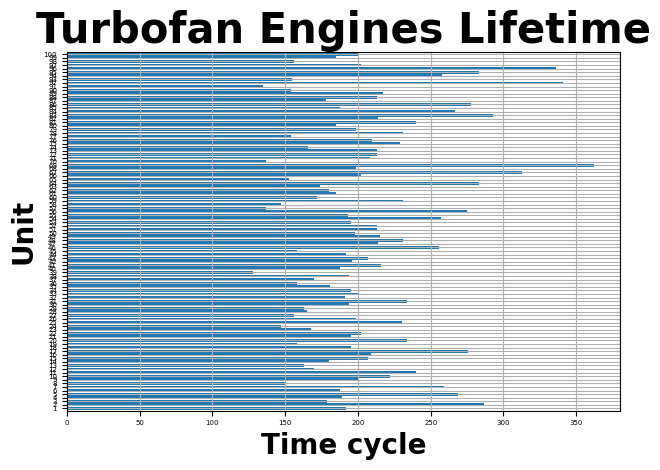

In [ ]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt

# Group by 'unit_number' and find the max 'time_cycles'
max_time_cycles_df = dftrain.groupBy('unit_number').agg(F.max('time_cycles').alias('max_time_cycles'))

# Collect the data to the driver node
max_time_cycles_pd = max_time_cycles_df.toPandas().sort_values('unit_number')

plt.figure(figsize=(60, 150))
ax = max_time_cycles_pd.plot(kind='barh', x='unit_number', y='max_time_cycles', width=0.8, stacked=True, align='center', legend=False)
plt.title('Turbofan Engines Lifetime', fontweight='bold', size=30)
plt.xlabel('Time cycle', fontweight='bold', size=20)
plt.xticks(size=5)
plt.ylabel('Unit', fontweight='bold', size=20)
plt.yticks(size=5)
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
print(max_time_cycles_pd.columns)


Index(['unit_number', 'max_time_cycles'], dtype='object')


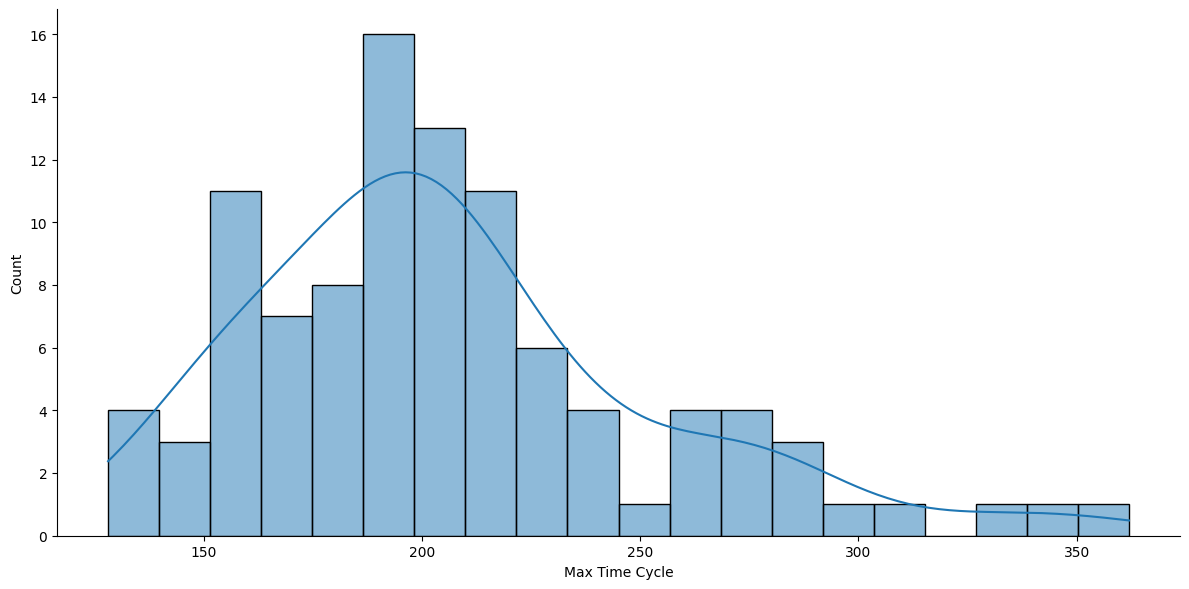

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Distribution of maximum time cycles using Seaborn
sns.displot(max_time_cycles_pd['max_time_cycles'], kde=True, bins=20, height=6, aspect=2)
plt.xlabel('Max Time Cycle')
plt.show()


We notice that in most of the time, the maximum time cycles that an engine can achieve is between 190 and 210 before HPC failure.

Add RUL column to the data
RUL corresponds to the remaining time cycles for each unit before it fails.

In [ ]:
from pyspark.sql import Window
from pyspark.sql.functions import max as spark_max
from pyspark.sql.functions import col

def add_RUL_column(df):
    # Create a window partitioned by 'unit_number' and calculate the max 'time_cycles' for each partition
    window = Window.partitionBy("unit_number")
    max_time_cycles = df.withColumn("max_time_cycle", spark_max("time_cycles").over(window))

    # Calculate RUL for each row and drop the 'max_time_cycle' column
    df_with_RUL = max_time_cycles.withColumn("RUL", col("max_time_cycle") - col("time_cycles")).drop("max_time_cycle")

    return df_with_RUL

# Apply the function to the DataFrame
df_with_RUL = add_RUL_column(dftrain)

# Show the DataFrame with the 'unit_number' and 'RUL'
df_with_RUL.select("unit_number", "RUL").show()

+-----------+---+
|unit_number|RUL|
+-----------+---+
|          1|191|
|          1|190|
|          1|189|
|          1|188|
|          1|187|
|          1|186|
|          1|185|
|          1|184|
|          1|183|
|          1|182|
|          1|181|
|          1|180|
|          1|179|
|          1|178|
|          1|177|
|          1|176|
|          1|175|
|          1|174|
|          1|173|
|          1|172|
+-----------+---+
only showing top 20 rows



In [ ]:
from pyspark.sql.functions import col, max as spark_max

# List of columns for which you want the max value
agg_cols = [spark_max(col(c)).alias(c) for c in df_with_RUL.columns if c != 'unit_number']

# Perform the groupBy operation and aggregate
maxrul_u = df_with_RUL.groupBy('unit_number').agg(*agg_cols)

# Order the result by 'unit_number' for readability
maxrul_u = maxrul_u.orderBy('unit_number')

# Show the result
maxrul_u.show(5)


+-----------+-----------+---------+---------+---------+------+------+-------+-------+-----+-----+------+-------+-------+----+-----+------+-------+-------+------+----+-----+------+-----+-----+-------+---+
|unit_number|time_cycles|setting_1|setting_2|setting_3|   s_1|   s_2|    s_3|    s_4|  s_5|  s_6|   s_7|    s_8|    s_9|s_10| s_11|  s_12|   s_13|   s_14|  s_15|s_16| s_17|  s_18| s_19| s_20|   s_21|RUL|
+-----------+-----------+---------+---------+---------+------+------+-------+-------+-----+-----+------+-------+-------+----+-----+------+-------+-------+------+----+-----+------+-----+-----+-------+---+
|          1|        192|   0.0047|   5.0E-4|    100.0|518.67|644.21|1605.44|1432.52|14.62|21.61|554.96|2388.32|9061.21| 1.3|48.33|522.86|2388.35|8140.58|8.5227|0.03|398.0|2388.0|100.0|39.18|23.4999|191|
|          2|        287|   0.0076|   6.0E-4|    100.0|518.67|643.94| 1610.1|1431.17|14.62|21.61|555.45|2388.24|9109.36| 1.3|48.27|523.26|2388.26|8175.57|8.5377|0.03|398.0|2388.0|100.0

#Discovering Correlations

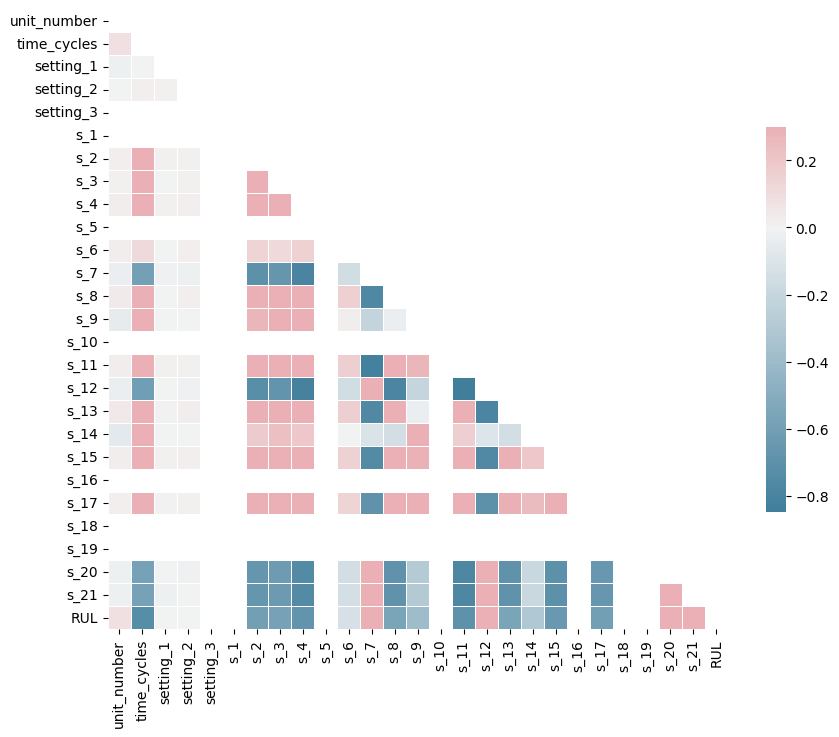

In [ ]:
from pyspark.sql.types import IntegerType, FloatType, DoubleType
from pyspark.sql.functions import col
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'df_with_RUL' is the DataFrame from which you want to calculate the correlation matrix
# First, let's get the list of numerical columns for which we want to compute the correlation
numerical_cols = [field.name for field in df_with_RUL.schema.fields if isinstance(field.dataType, (IntegerType, FloatType, DoubleType))]

# Initialize an empty dictionary to store correlation values
corr_matrix = {c: {c2: None for c2 in numerical_cols} for c in numerical_cols}

# Calculate the correlation for each pair of numerical columns and store in the dictionary
for col1 in numerical_cols:
    for col2 in numerical_cols:
        corr_matrix[col1][col2] = df_with_RUL.stat.corr(col1, col2)



# Convert the correlation matrix dictionary to a pandas DataFrame
corr_matrix_pd = pd.DataFrame(corr_matrix)

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr_matrix_pd, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(10, 10))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 10, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr_matrix_pd, mask=mask, cmap=cmap, vmax=.3, center=0, square=True, linewidths=.5, cbar_kws={"shrink": .5})

# Show the plot
plt.show()


We notice that some features of our data-set are highly correlated with the target value RUL, other features present a low correlation which will be dropped later.

First, let us match each sensor with its real signification

In [ ]:
def create_sensor_dictionary():
    sensor_dictionary = {}
    dict_list = [
        "(Fan inlet temperature) (◦R)",
        "(LPC outlet temperature) (◦R)",
        "(HPC outlet temperature) (◦R)",
        "(LPT outlet temperature) (◦R)",
        "(Fan inlet Pressure) (psia)",
        "(bypass-duct pressure) (psia)",
        "(HPC outlet pressure) (psia)",
        "(Physical fan speed) (rpm)",
        "(Physical core speed) (rpm)",
        "(Engine pressure ratio(P50/P2)",
        "(HPC outlet Static pressure) (psia)",
        "(Ratio of fuel flow to Ps30) (pps/psia)",
        "(Corrected fan speed) (rpm)",
        "(Corrected core speed) (rpm)",
        "(Bypass Ratio) ",
        "(Burner fuel-air ratio)",
        "(Bleed Enthalpy)",
        "(Required fan speed)",
        "(Required fan conversion speed)",
        "(High-pressure turbines Cool air flow)",
        "(Low-pressure turbines Cool air flow)"
    ]
    for i, sensor_name in enumerate(dict_list, 1):
        sensor_dictionary[f's_{i}'] = sensor_name
    return sensor_dictionary

sensor_dictionary = create_sensor_dictionary()

# Print the dictionary with each item on a new line
for sensor, description in sensor_dictionary.items():
    print(f"'{sensor}': '{description}',")


's_1': '(Fan inlet temperature) (◦R)',
's_2': '(LPC outlet temperature) (◦R)',
's_3': '(HPC outlet temperature) (◦R)',
's_4': '(LPT outlet temperature) (◦R)',
's_5': '(Fan inlet Pressure) (psia)',
's_6': '(bypass-duct pressure) (psia)',
's_7': '(HPC outlet pressure) (psia)',
's_8': '(Physical fan speed) (rpm)',
's_9': '(Physical core speed) (rpm)',
's_10': '(Engine pressure ratio(P50/P2)',
's_11': '(HPC outlet Static pressure) (psia)',
's_12': '(Ratio of fuel flow to Ps30) (pps/psia)',
's_13': '(Corrected fan speed) (rpm)',
's_14': '(Corrected core speed) (rpm)',
's_15': '(Bypass Ratio) ',
's_16': '(Burner fuel-air ratio)',
's_17': '(Bleed Enthalpy)',
's_18': '(Required fan speed)',
's_19': '(Required fan conversion speed)',
's_20': '(High-pressure turbines Cool air flow)',
's_21': '(Low-pressure turbines Cool air flow)',


A low pressure compressor (LPC) and high pressure compressor (HPC) supply compressed high temperature, high pressure gases to the combustor. Low pressure turbine (LPT) can decelerate and pressurize air to improve the chemical energy conversion efficiency of aviation kerosene. High pressure turbines (HPT) generate mechanical energy by using high temperature and high pressure gas strike turbine blades. Low-pressure rotor (N1), high-pressure rotor (N2), and nozzle guarantee the combustion efficiency of the engine.

Plotting the evolution of features (sensors) along with the evolution with RUL

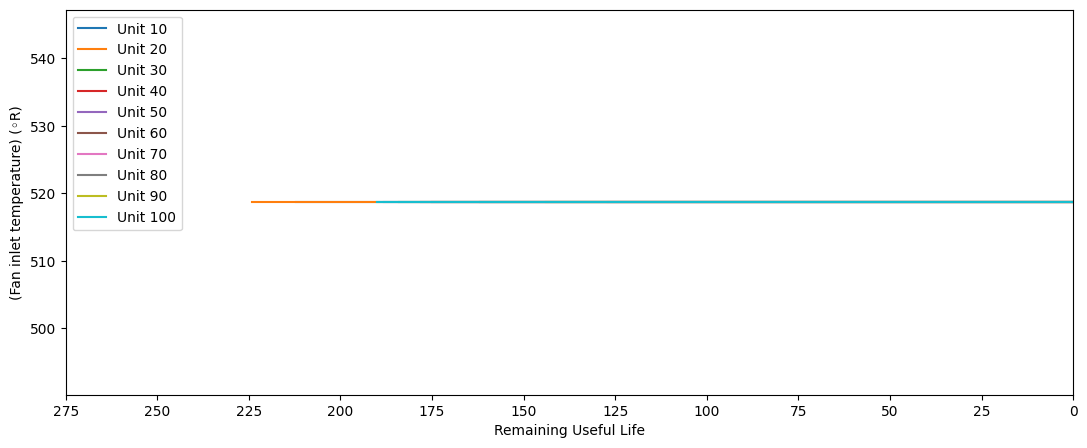

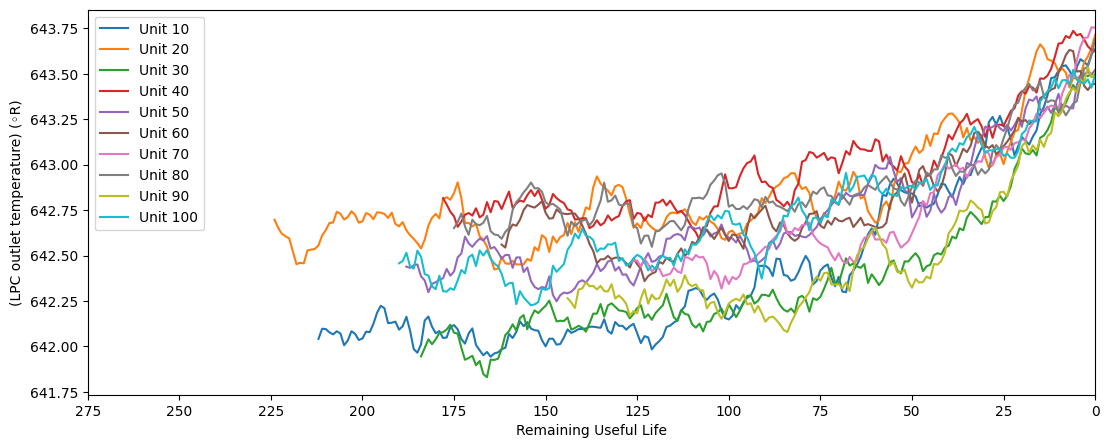

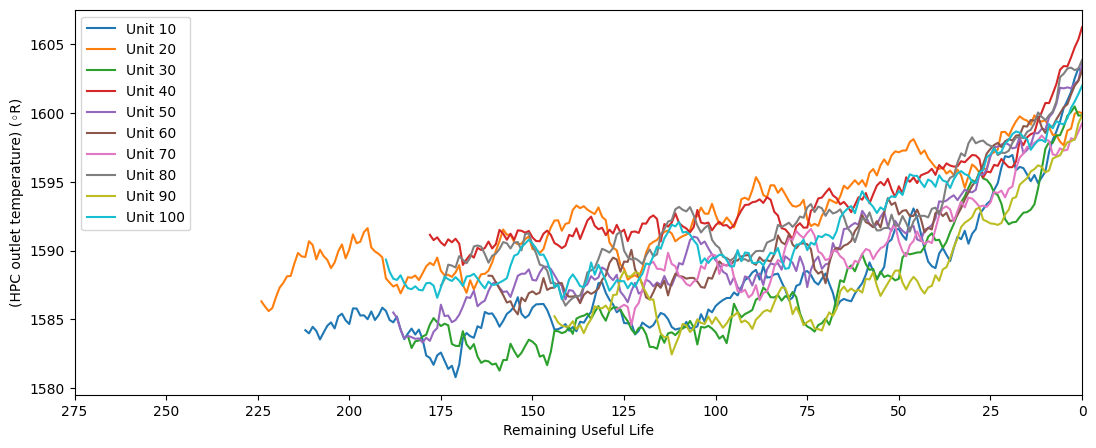

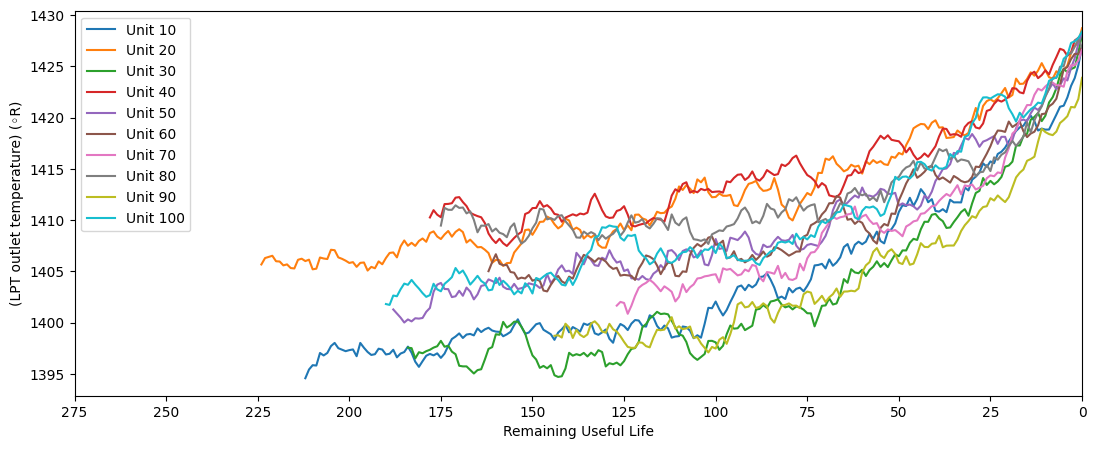

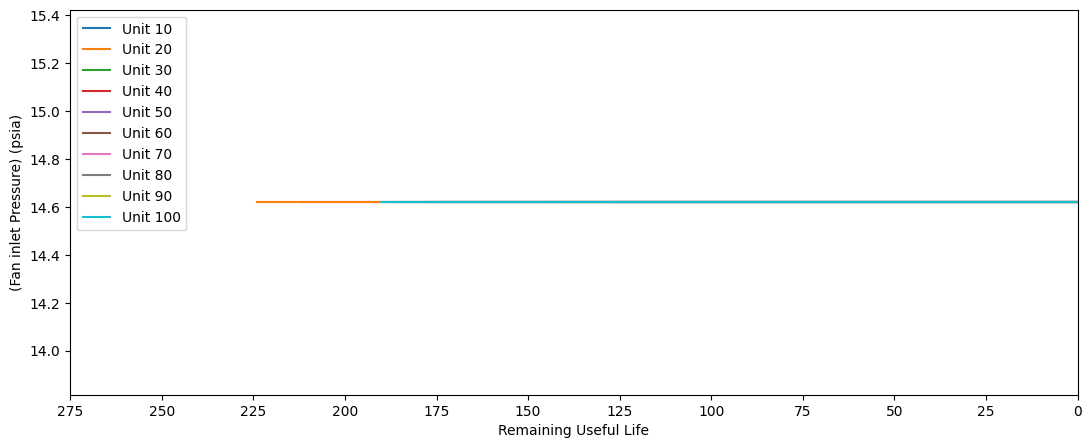

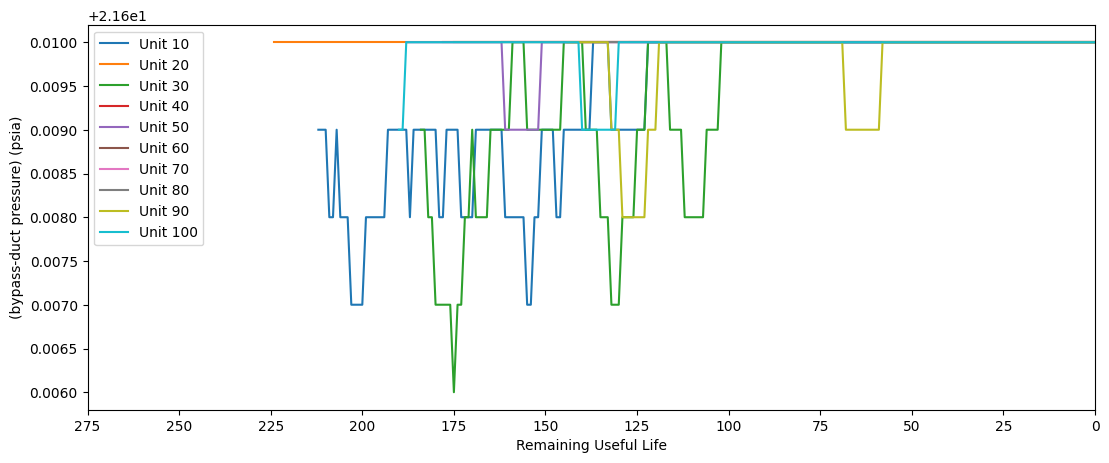

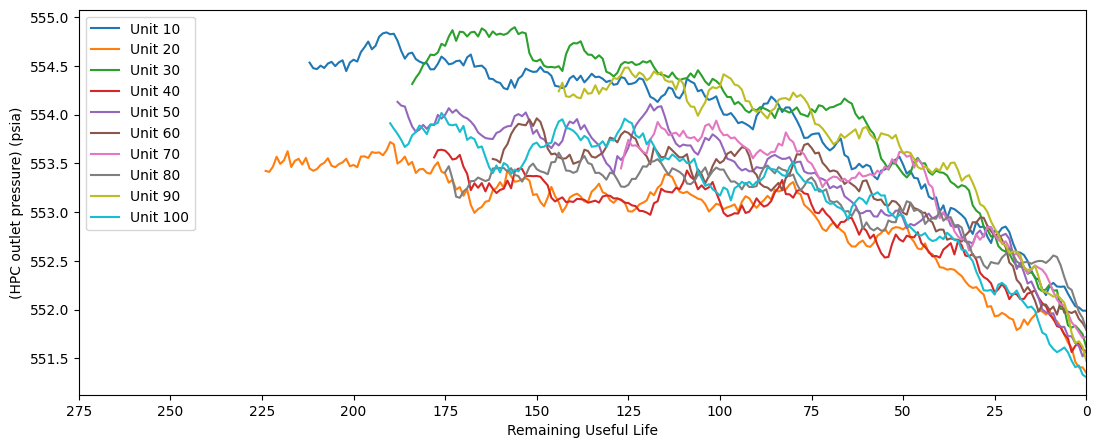

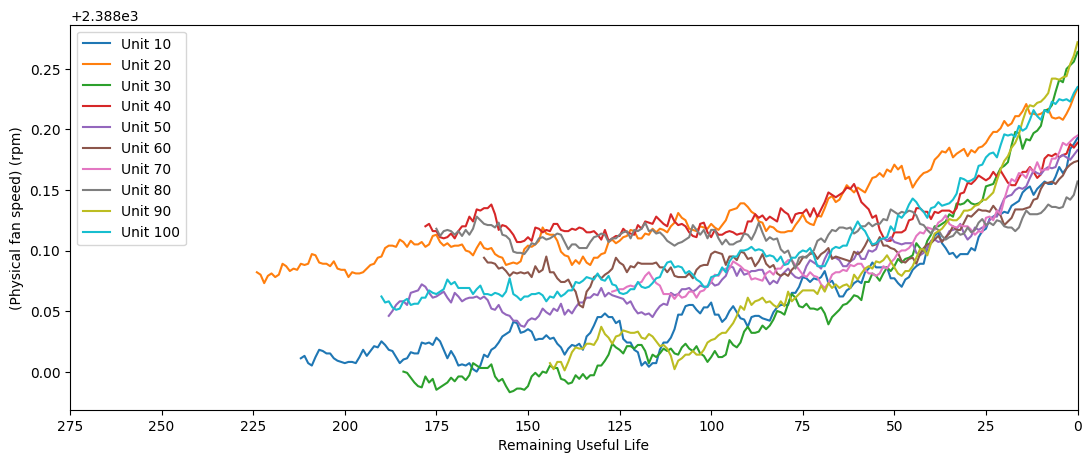

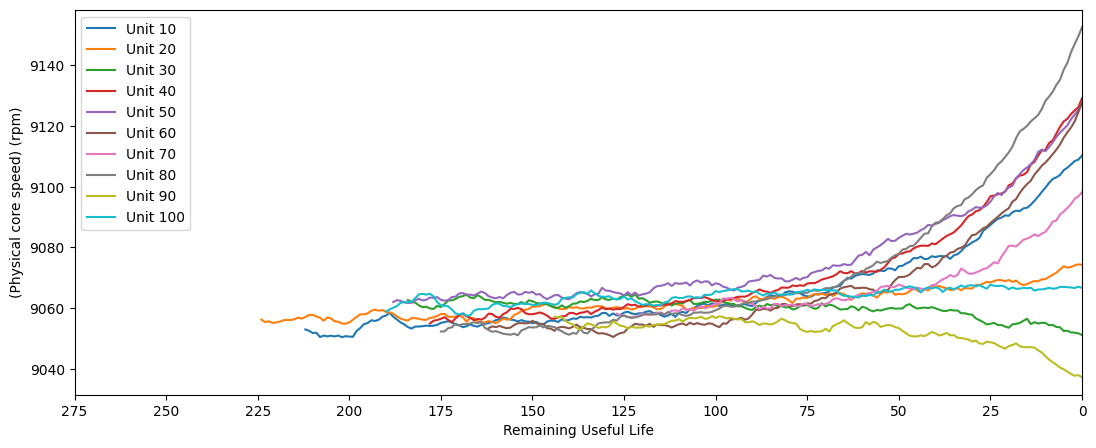

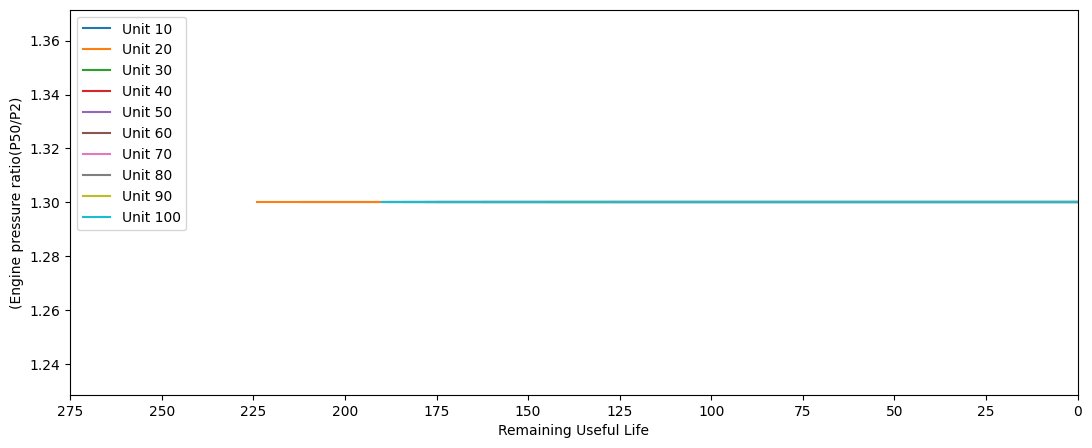

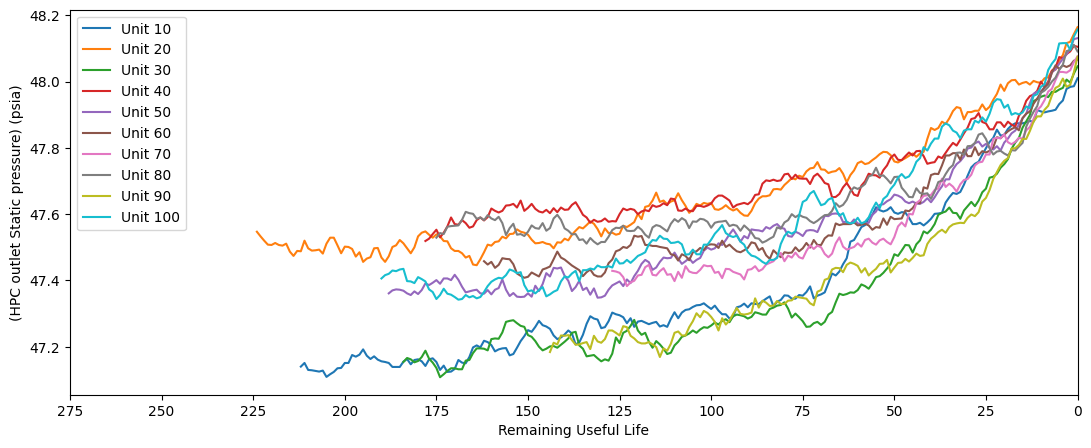

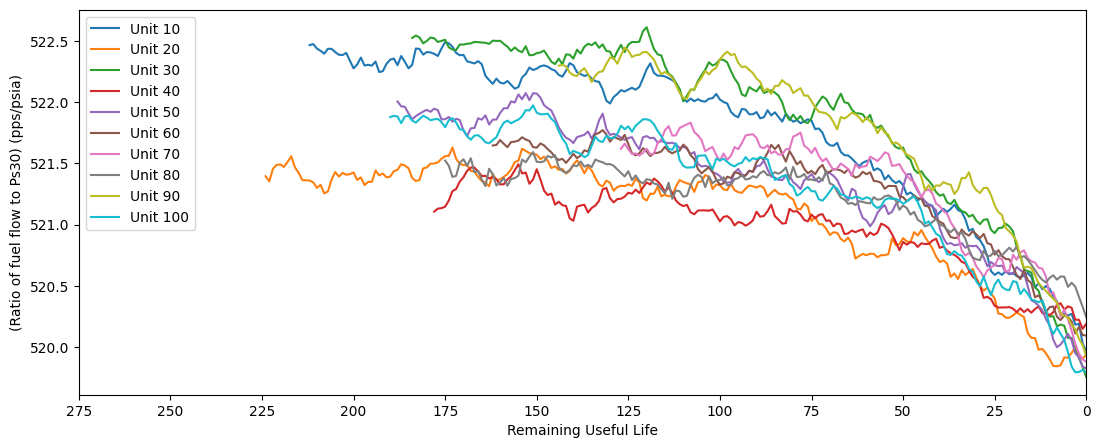

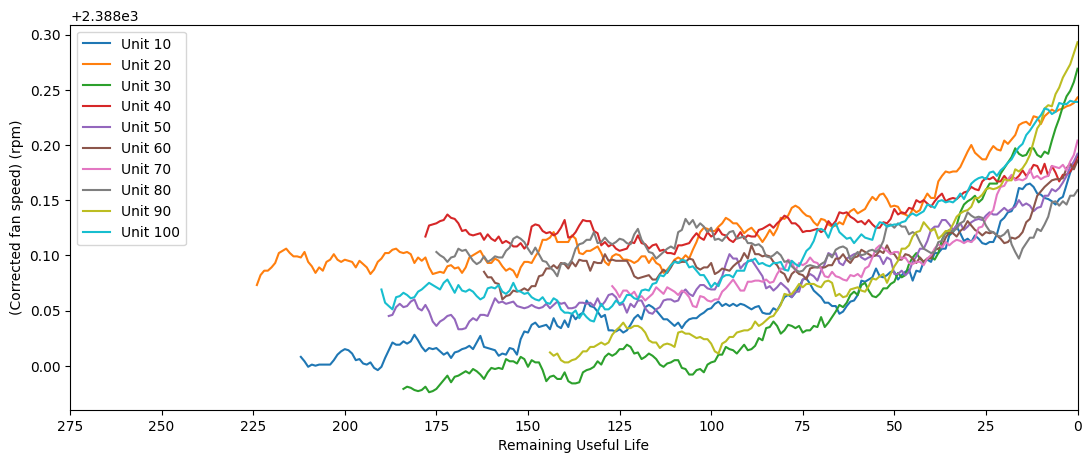

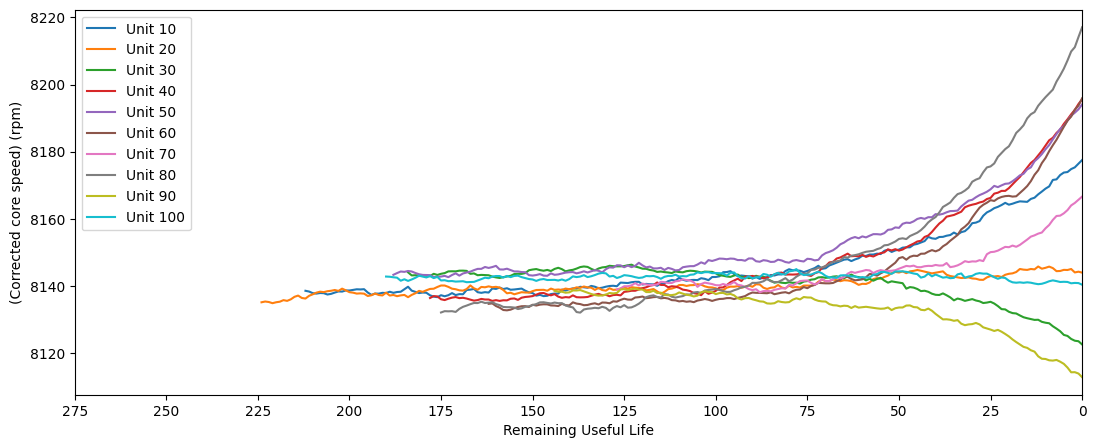

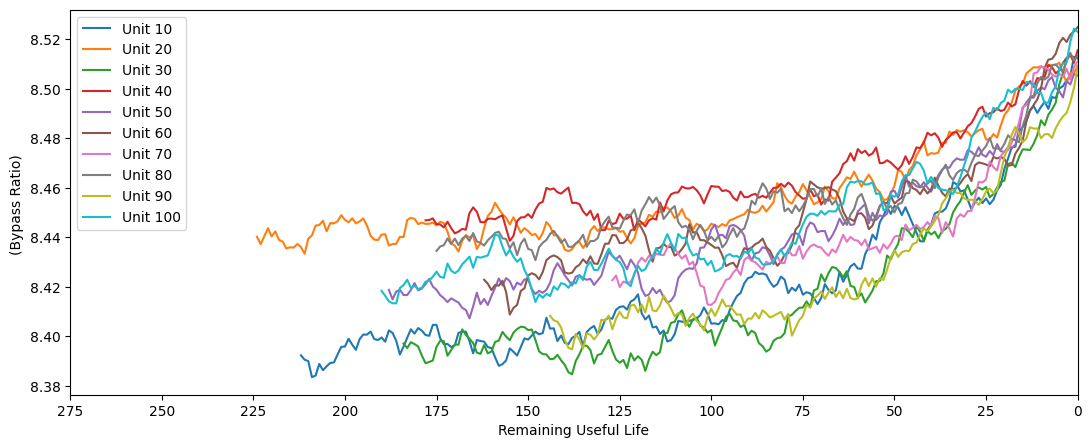

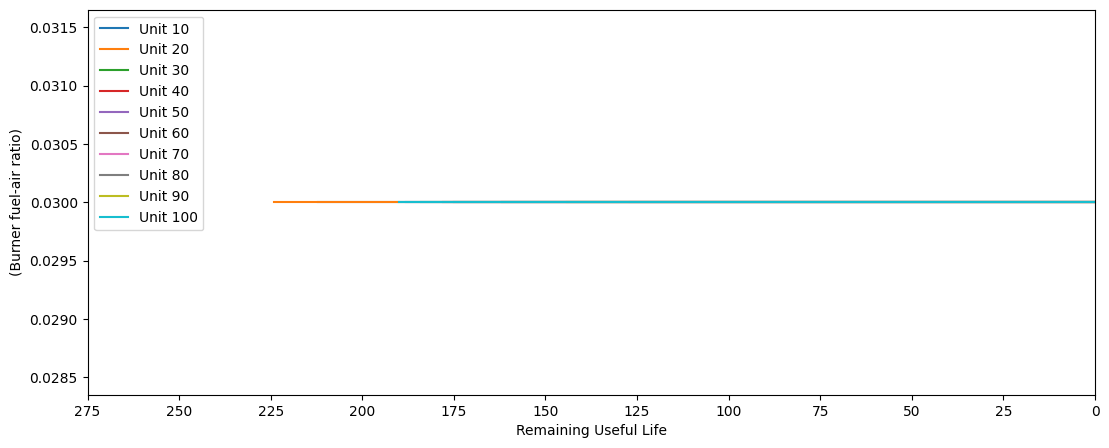

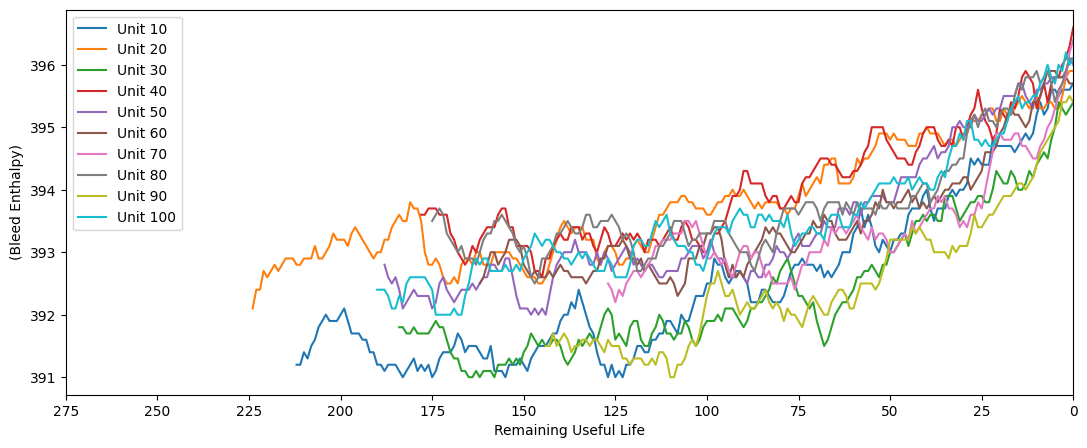

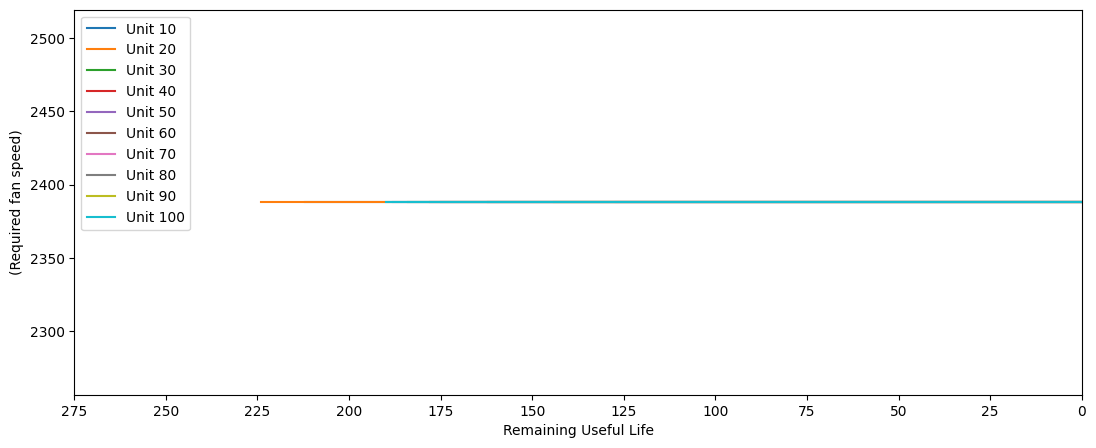

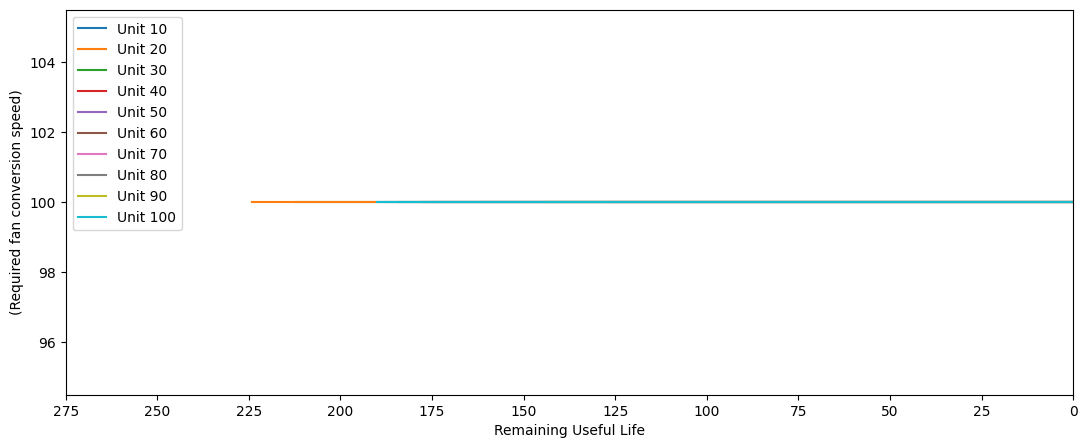

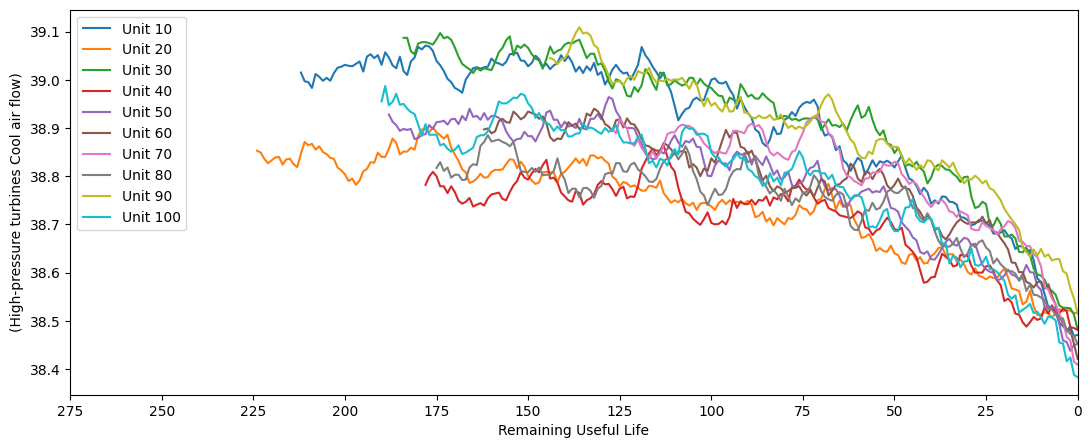

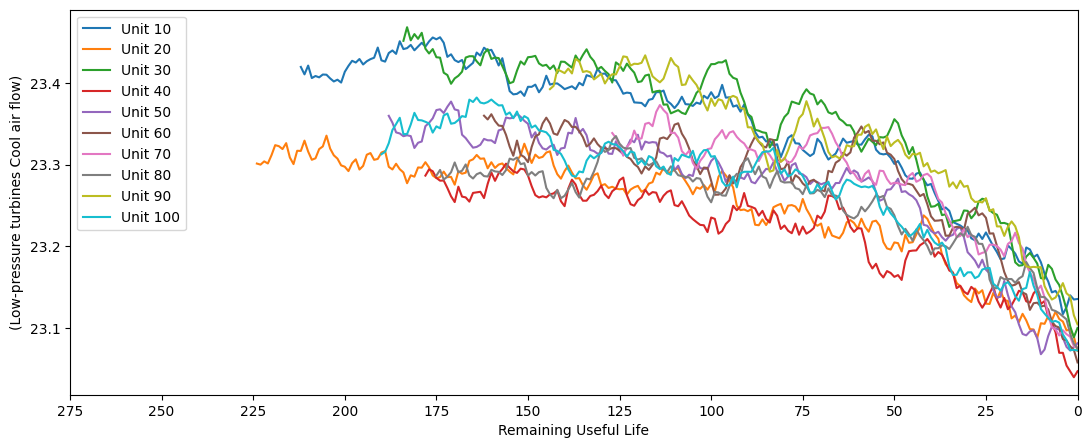

In [ ]:
from pyspark.sql.functions import col
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Define the function to sample units and collect data as a pandas DataFrame
def sample_and_collect(df, sensor_name):
    # Filter units that we want to plot
    sampled_units = df.filter((col('unit_number') % 10) == 0).select('unit_number', 'RUL', sensor_name)

    # Convert to pandas for plotting
    pd_df = sampled_units.toPandas()

    return pd_df

# Define the plotting function
def plot_signal(pd_df, sensor_name, sensor_description):
    plt.figure(figsize=(13,5))
    unit_numbers = pd_df['unit_number'].unique()

    for unit in unit_numbers:
        unit_data = pd_df[pd_df['unit_number'] == unit]
        plt.plot(unit_data['RUL'], unit_data[sensor_name].rolling(window=10).mean(), label=f'Unit {unit}')

    plt.xlim(250, 0)  # reverse the x-axis so RUL counts down to zero
    plt.xticks(np.arange(0, 300, 25))
    plt.ylabel(sensor_description)
    plt.xlabel('Remaining Useful Life')
    plt.legend()
    plt.show()

# Loop through sensors and plot
for i in range(1, 22):
    sensor_name = f's_{i}'
    try:
        # Sample and collect data for the current sensor
        sampled_pd_df = sample_and_collect(df_with_RUL, sensor_name)

        # Plot the sensor data against RUL
        plot_signal(sampled_pd_df, sensor_name, sensor_dictionary[sensor_name])
    except KeyError:  # If the sensor name is not in the DataFrame, skip it
        print(f"{sensor_name} not found in the DataFrame.")
        continue


These plots show that some sensors are constant. Hence they don't influence the RUL ==> we can drop those ones. (later)

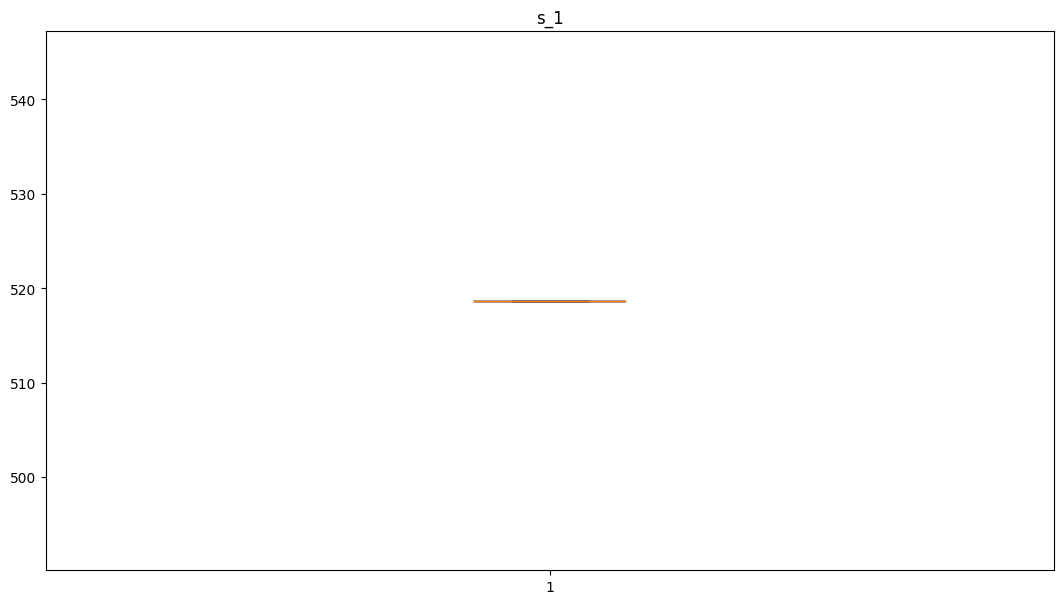

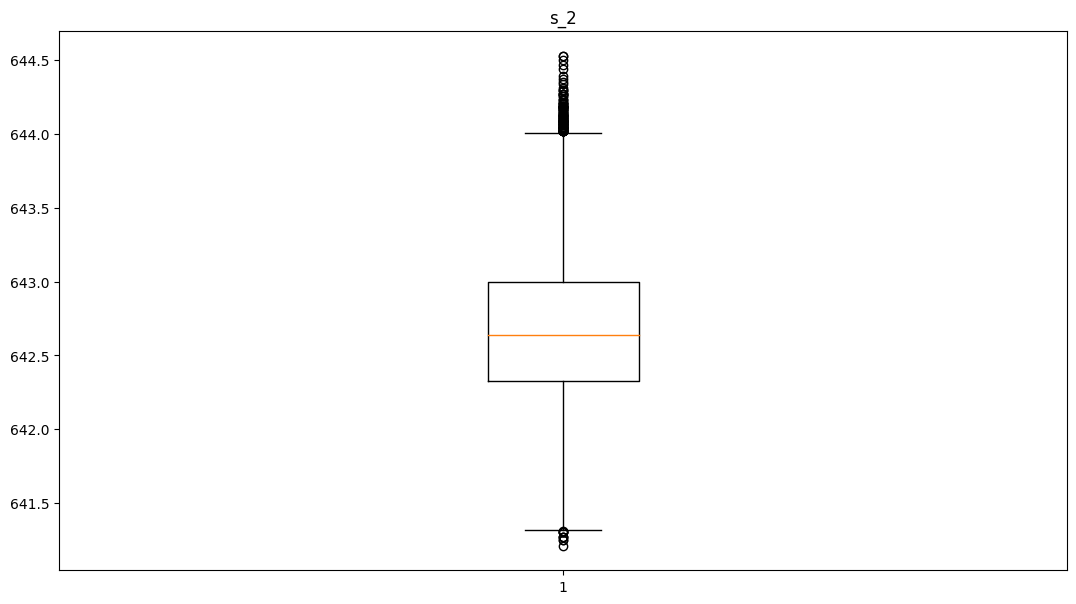

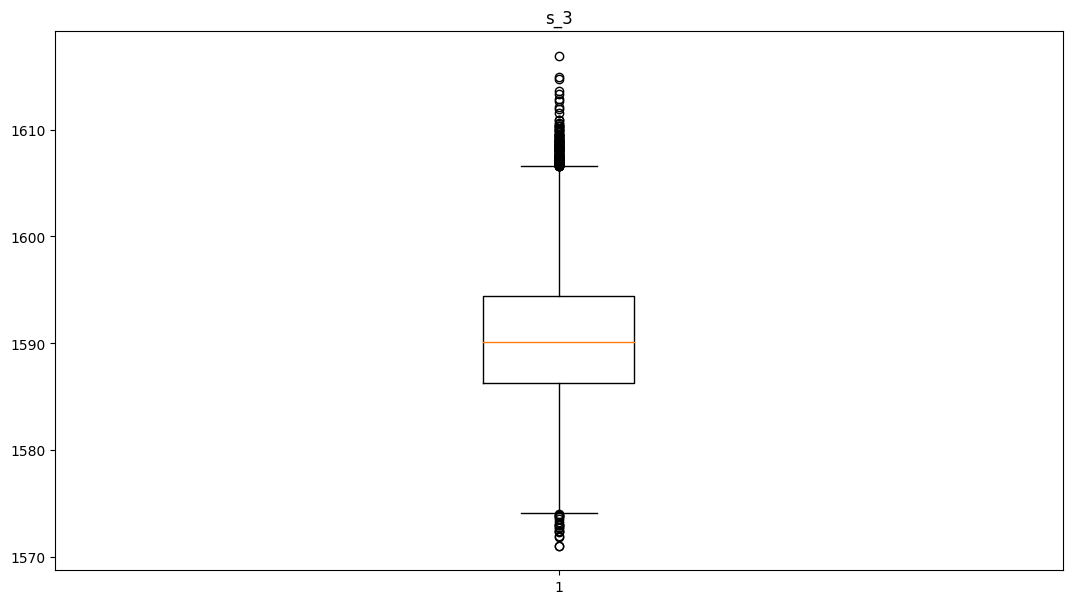

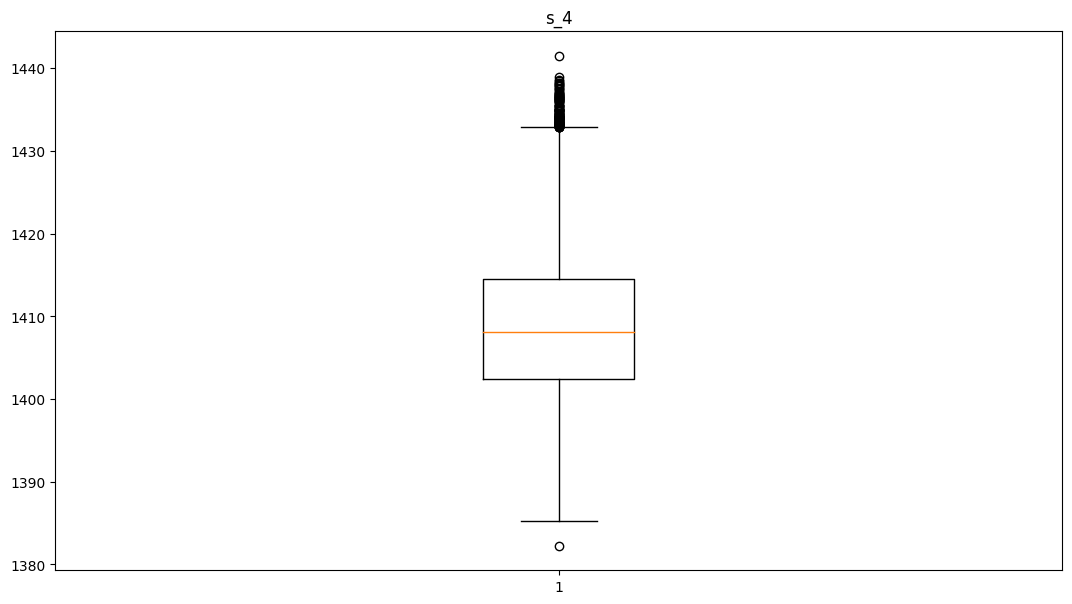

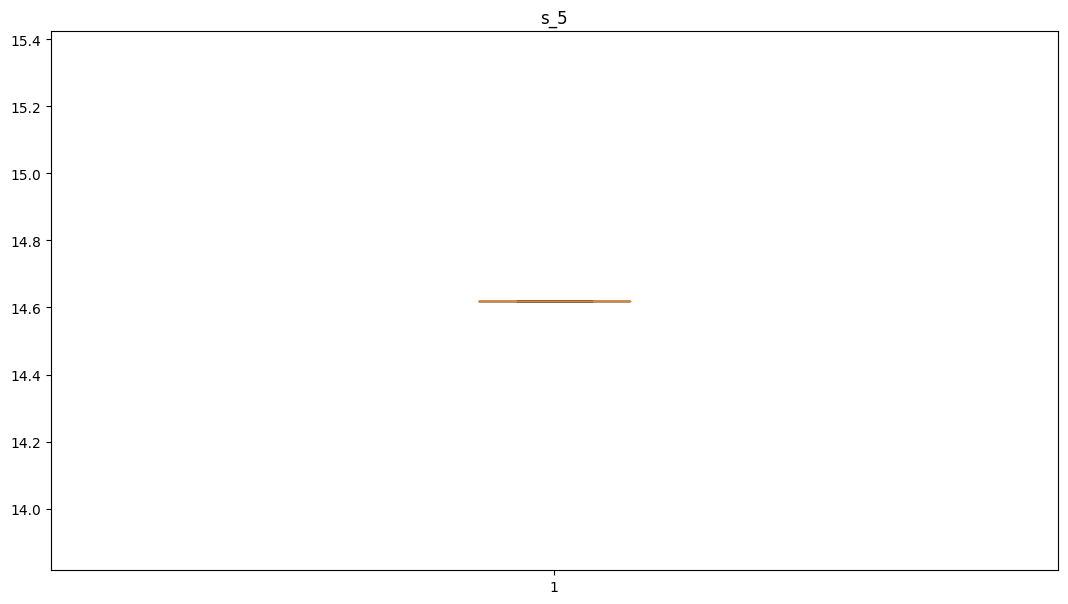

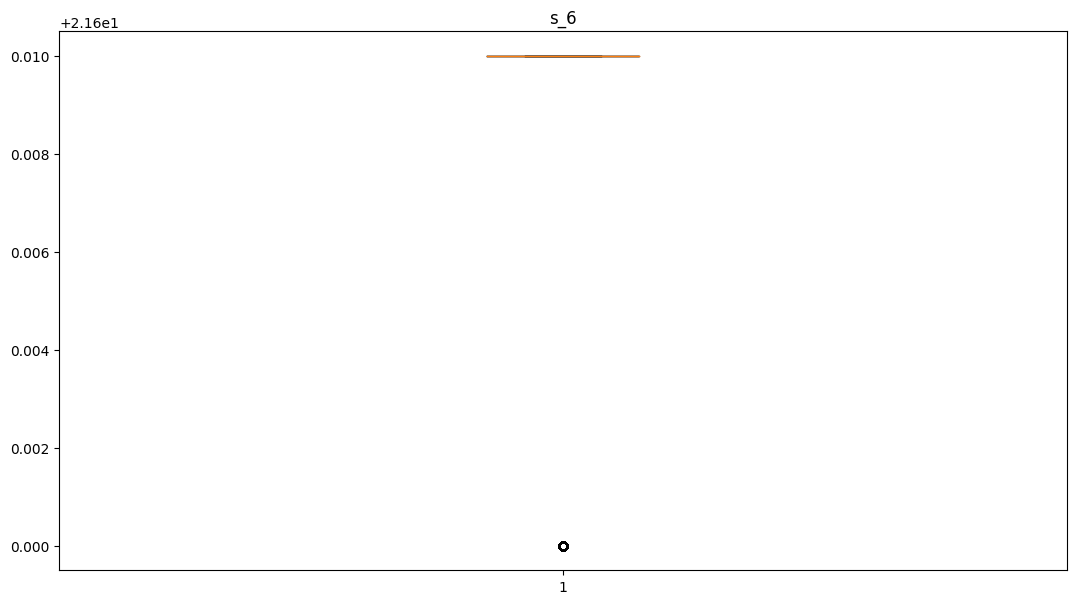

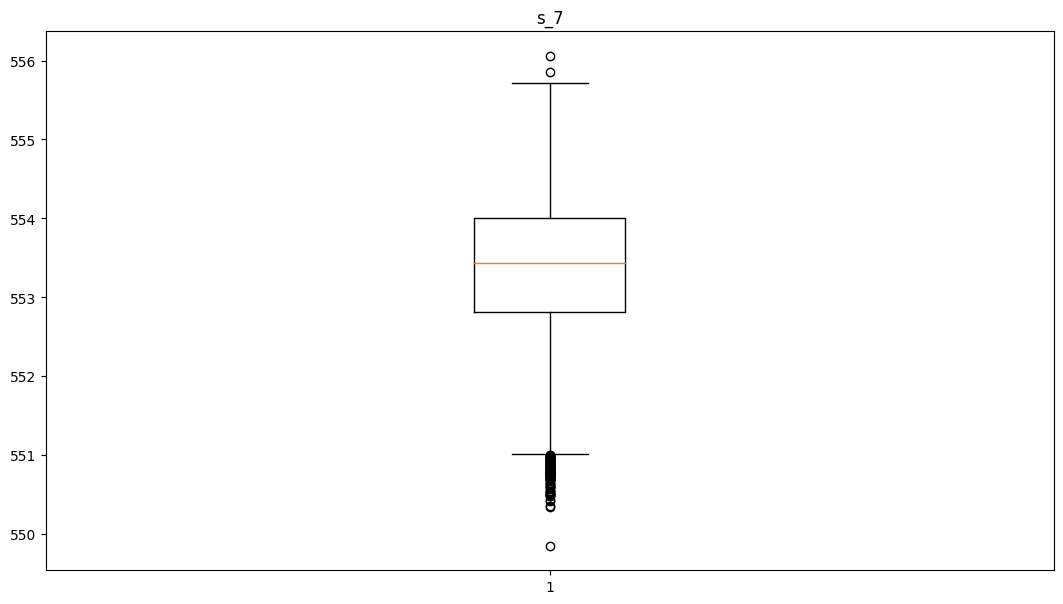

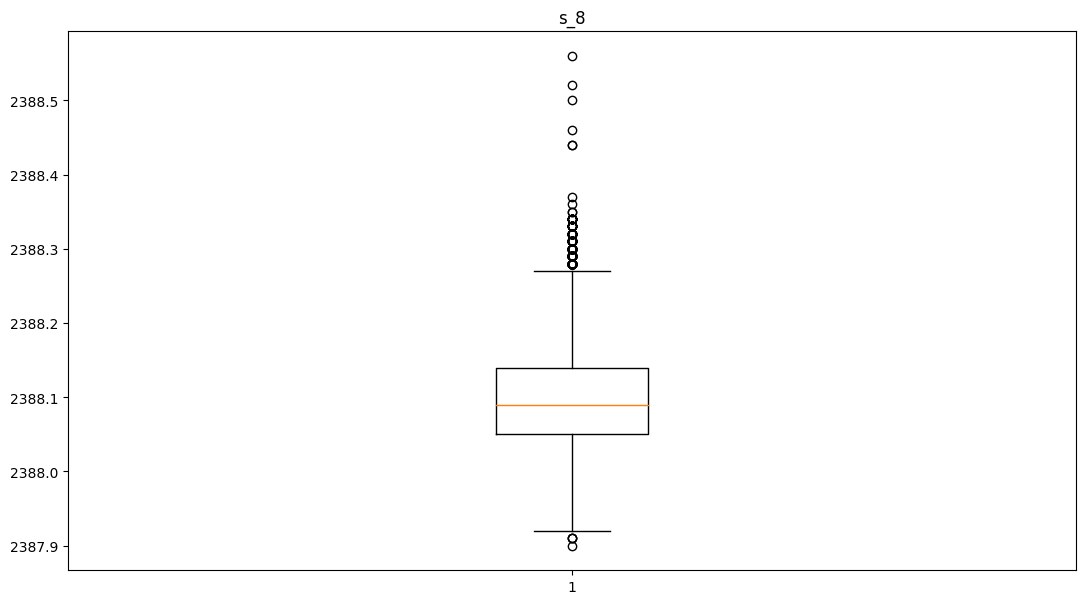

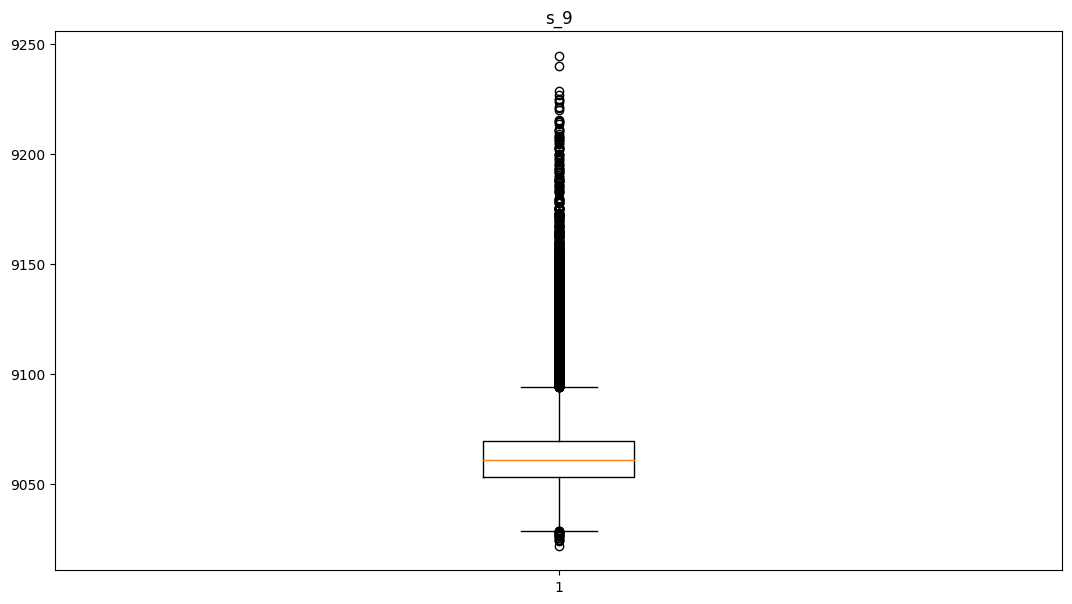

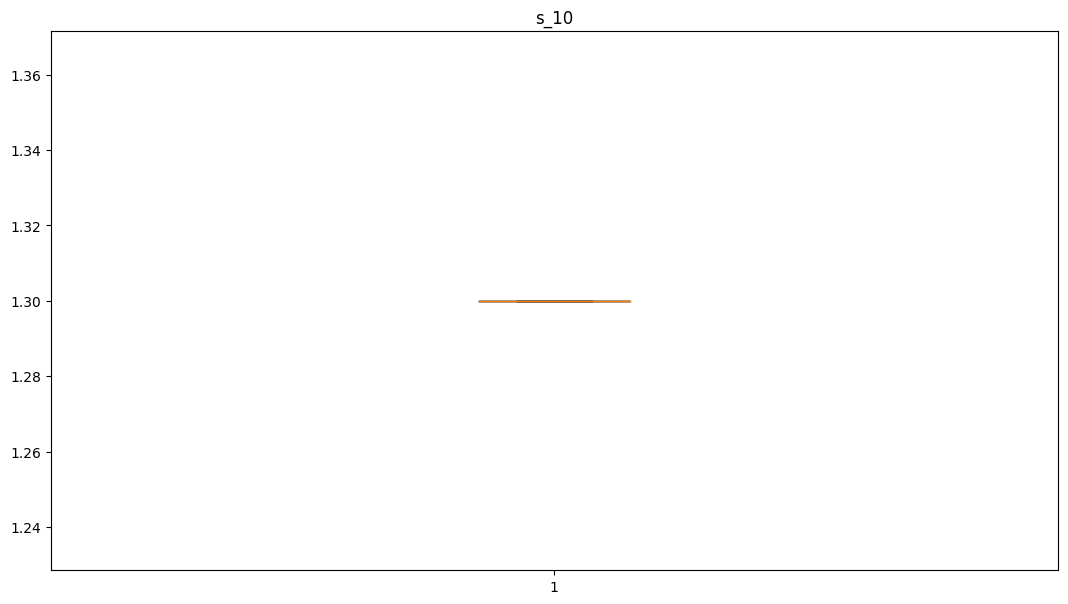

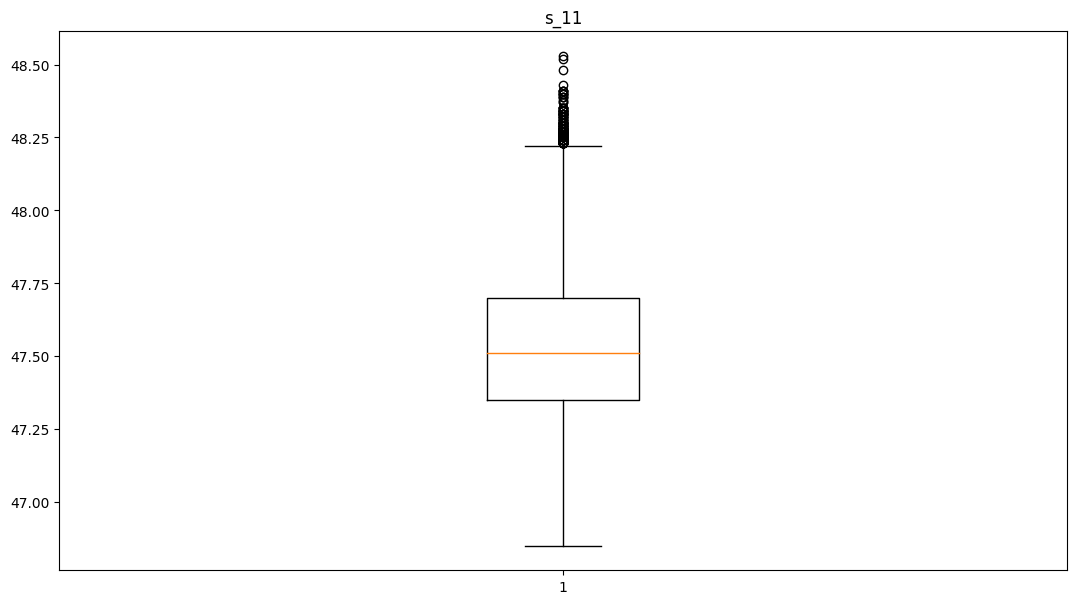

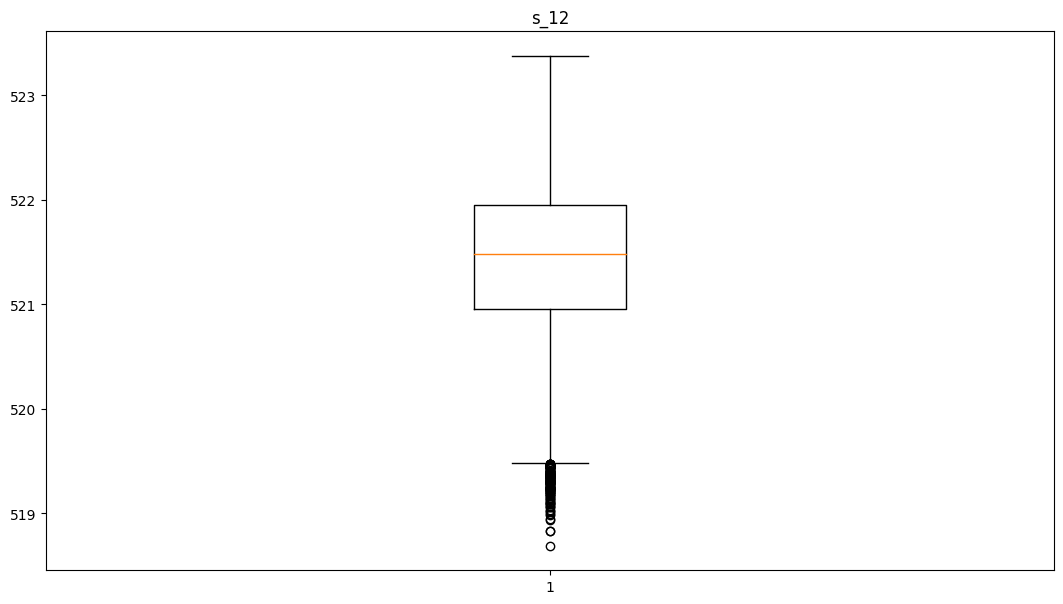

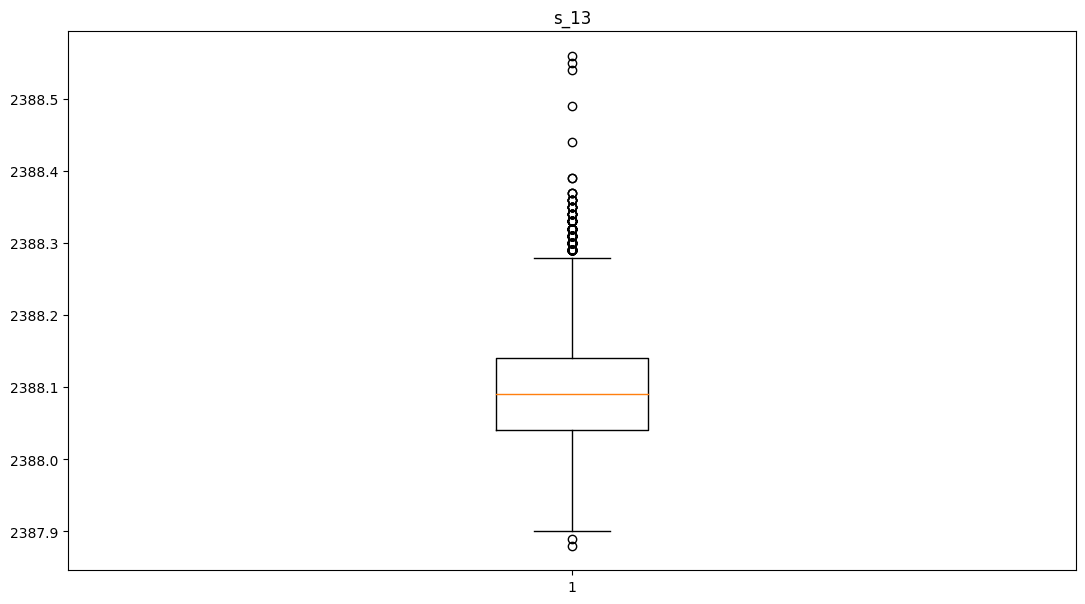

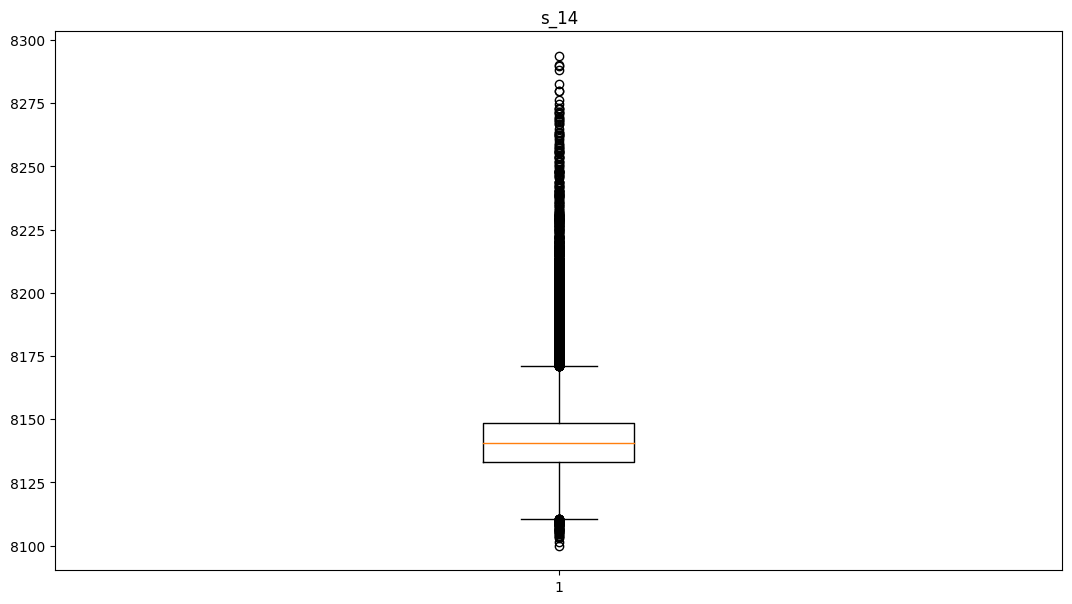

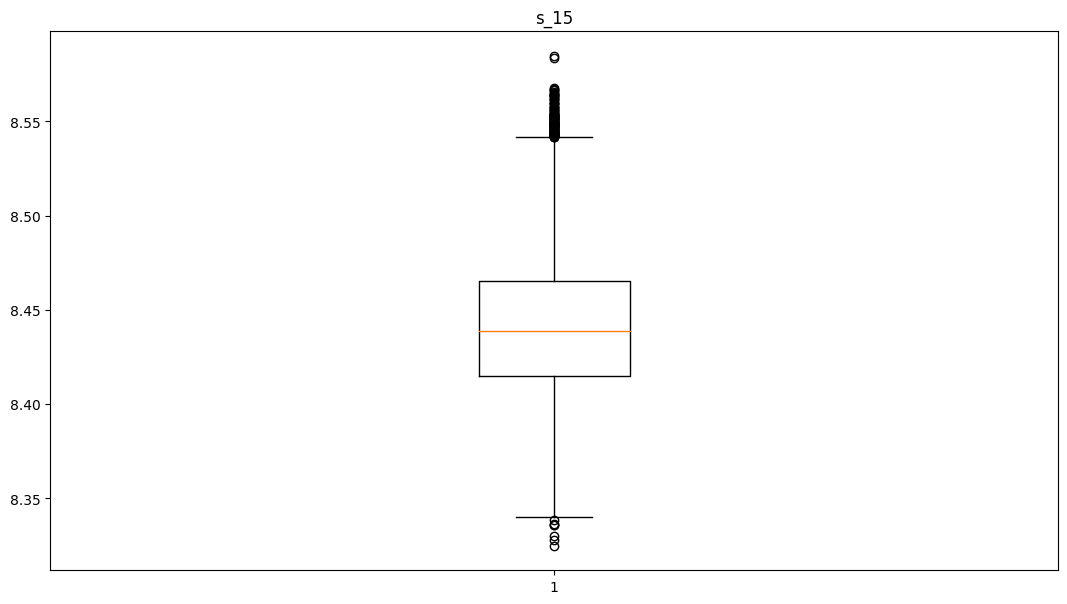

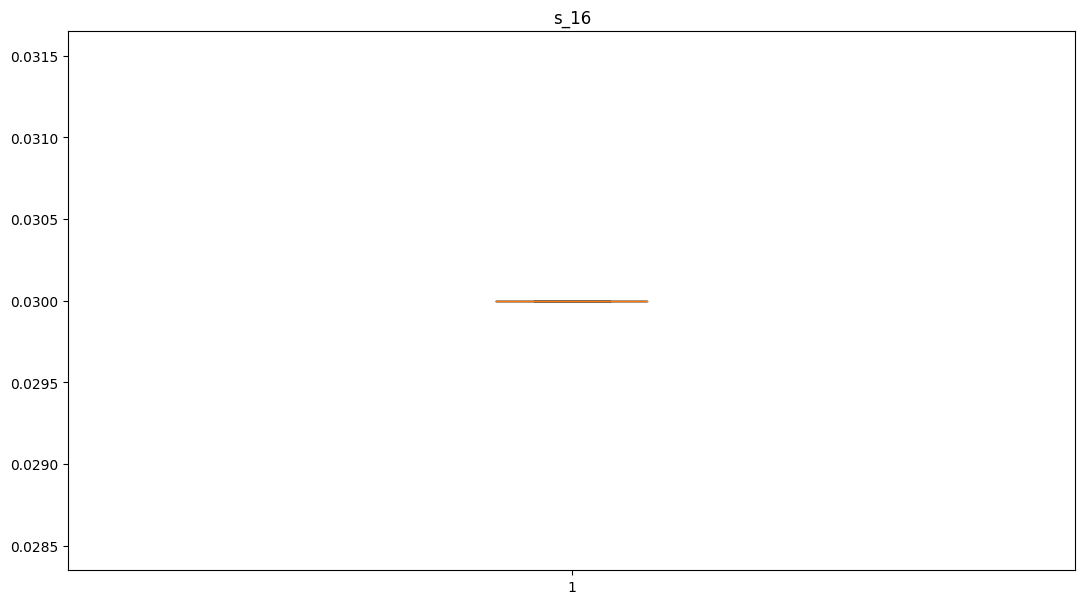

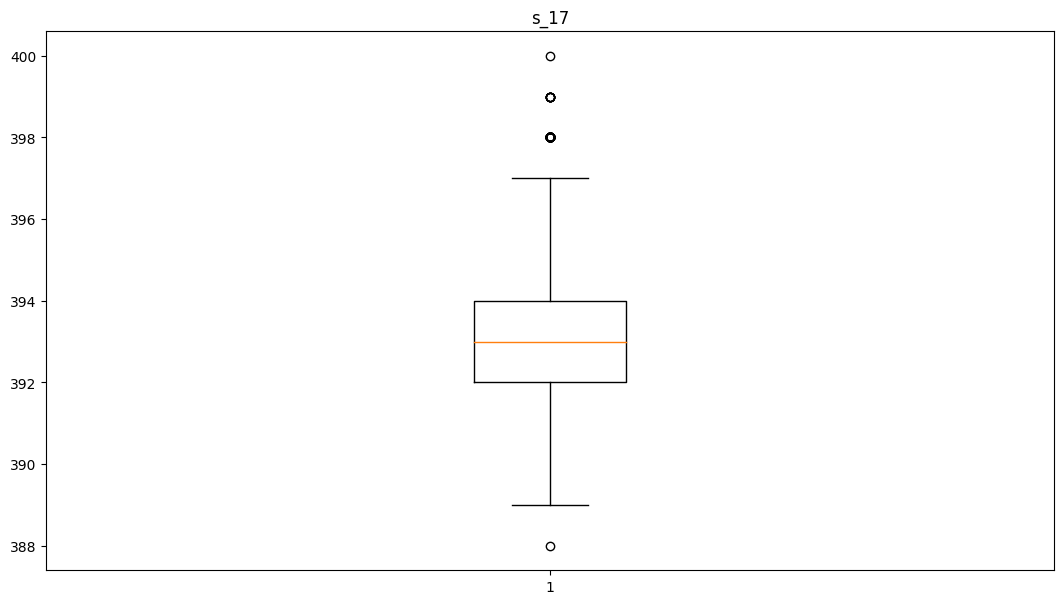

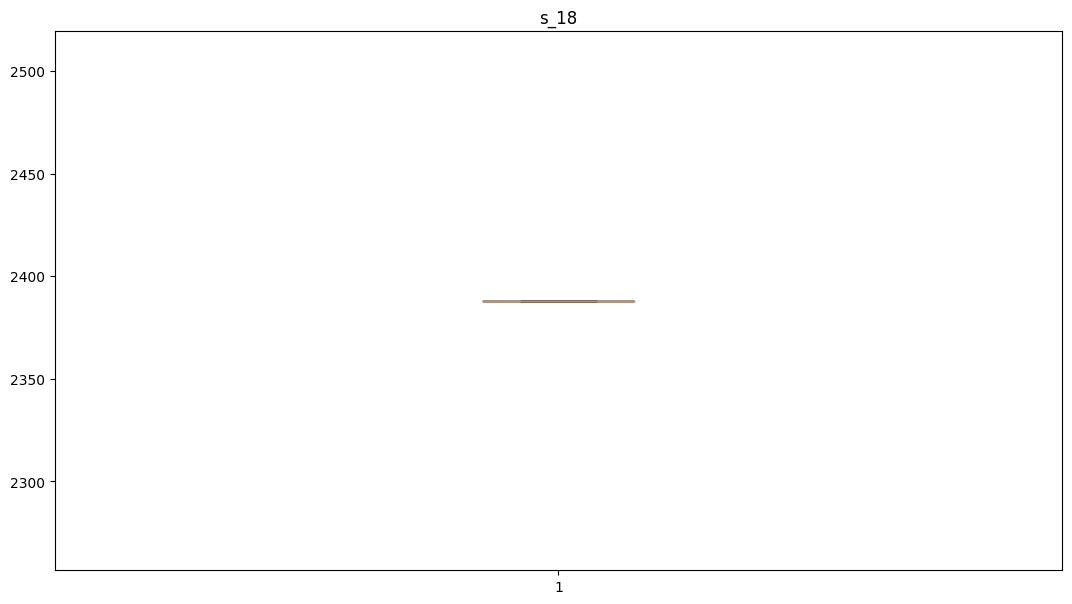

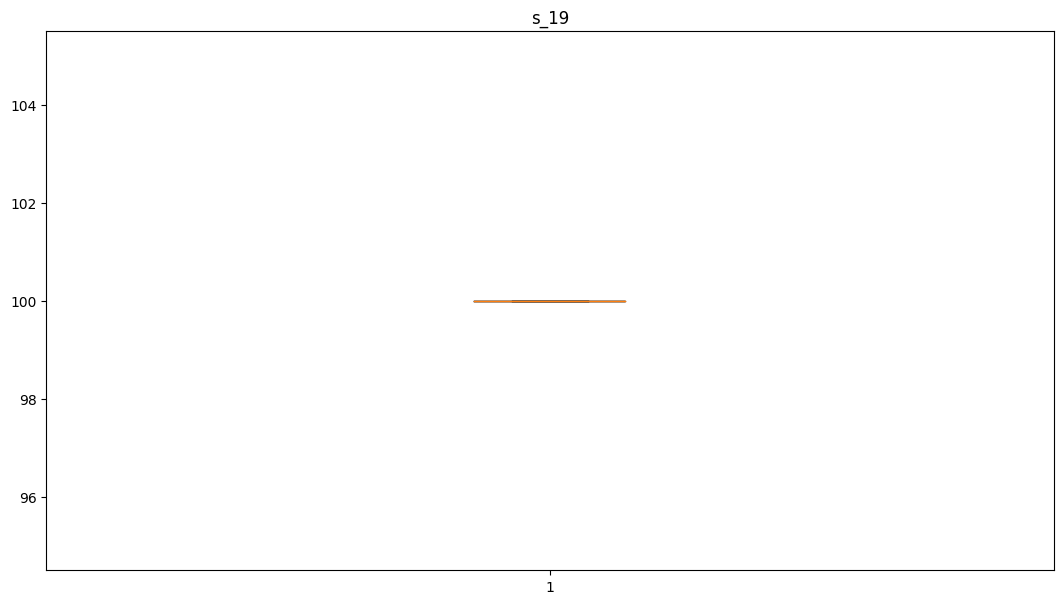

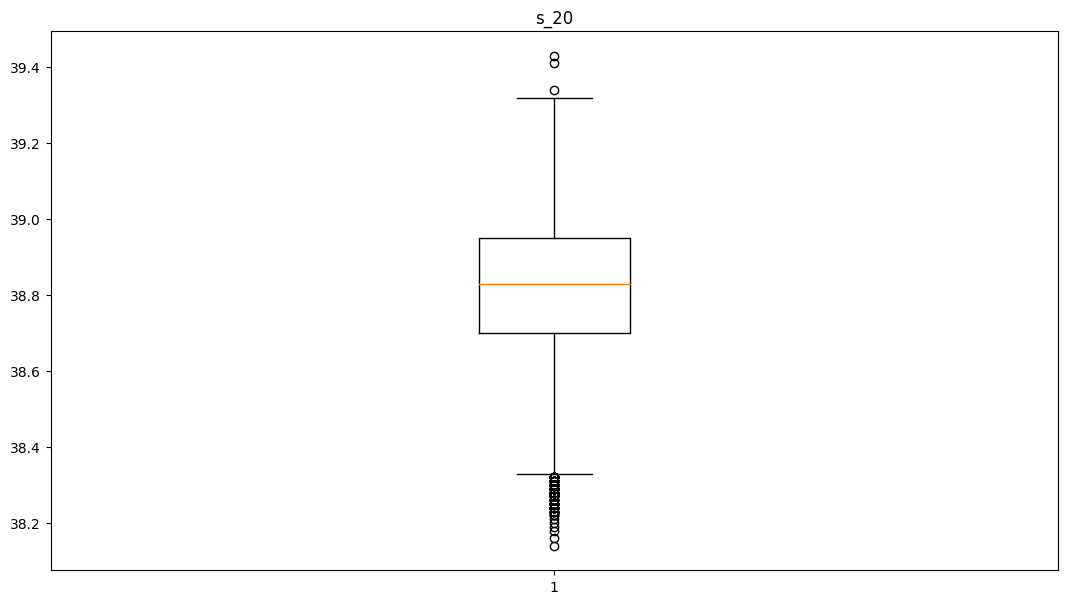

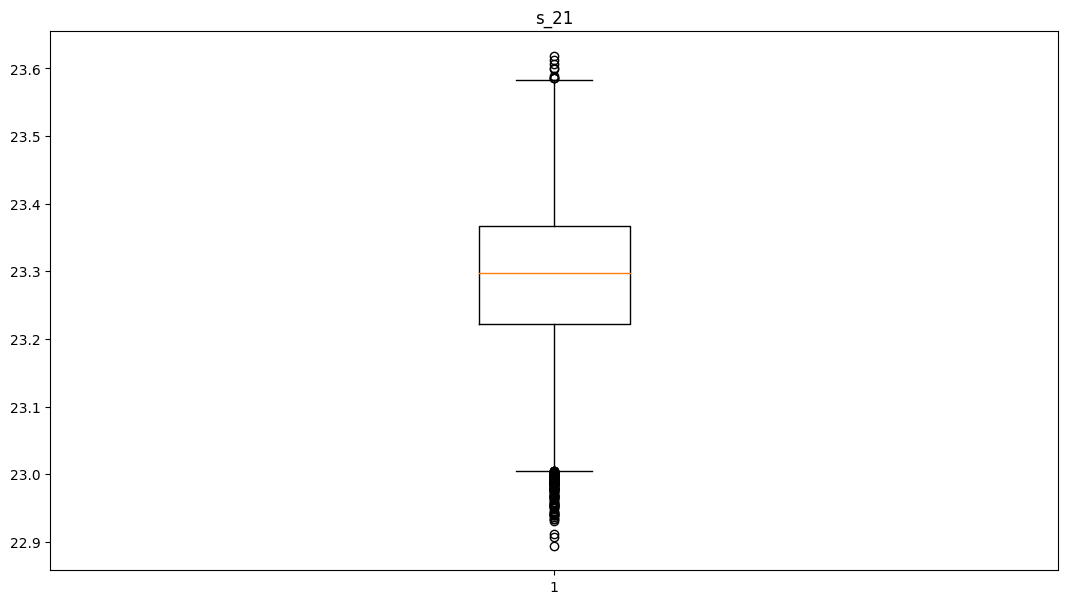

In [ ]:
import matplotlib.pyplot as plt

# Let's assume 'df_with_RUL' is your PySpark DataFrame and 'sensor_names' is your list of sensor columns

# Iterate over the sensor names
for x in sensor_names:
    # Collect the data for the current sensor
    # Use `.sample(False, 0.1)` to reduce the data size if necessary
    data = df_with_RUL.select(x).toPandas()

    # Plotting the boxplot for the current sensor
    plt.figure(figsize=(13, 7))
    plt.boxplot(data[x].dropna())  # Drop NA values for plotting
    plt.title(x)
    plt.show()


Observing the signal plots and the boxplots, we notice that the sensors 1,5,10,16,18,19 are constant, furthermore, we observe that the other sensors aren't well distributed and there are many outliers, then we should scale our data

In [ ]:
# Assuming 'maxrul_u' is your PySpark DataFrame that contains the 'RUL' column
# along with other sensor columns starting from 's_1'.

# Collect the list of sensor columns you want to describe, including 'RUL'.
columns_to_describe =  [col_name for col_name in maxrul_u.columns if col_name.startswith('s_')] + ['RUL']

# Compute summary statistics for the selected columns
summary_stats = maxrul_u.select(columns_to_describe).summary()

# Collect the summary statistics to the driver node as a Pandas DataFrame
summary_stats_pd = summary_stats.toPandas()

# Transpose the Pandas DataFrame for a format similar to pandas' describe().transpose()
transposed_summary_stats_pd = summary_stats_pd.set_index('summary').T

# Display the transposed DataFrame
transposed_summary_stats_pd


summary,count,mean,stddev,min,25%,50%,75%,max
s_1,100,518.6699829101562,0.0,518.67,518.67,518.67,518.67,518.67
s_2,100,644.1088000488281,0.14177481097002384,643.87,644.01,644.09,644.19,644.53
s_3,100,1608.0730993652344,2.4460589948367777,1604.07,1606.34,1607.67,1609.33,1616.91
s_4,100,1434.5064001464843,2.3237755311165373,1429.26,1432.64,1434.22,1436.27,1441.49
s_5,100,14.619999885559082,0.0,14.62,14.62,14.62,14.62,14.62
s_6,100,21.610000610351562,0.0,21.61,21.61,21.61,21.61,21.61
s_7,100,554.9071990966797,0.4967493979748222,553.99,554.52,554.87,555.31,556.06
s_8,100,2388.284123535156,0.0683788440717457,2388.18,2388.23,2388.29,2388.32,2388.56
s_9,100,9109.62041015625,50.604640437218805,9051.18,9070.09,9085.94,9153.32,9244.59
s_10,100,1.2999999523162842,0.0,1.3,1.3,1.3,1.3,1.3


The last point is more supported by the fact that the statistic properties of sensors data show that they don't have the same scale and they don't follow a normal distribution ==> this can be solved by performing a Minmax scaler on our data.

MinMax scaler function :Transform features by scaling each feature to a given range.

This estimator scales and translates each feature individually such that it is in the given range on the training setimage.png!

Dropping unnecessary features (labels and settings)

In [ ]:
from pyspark.sql.functions import col

# Assuming 'df_with_RUL' is your PySpark DataFrame and you have lists named 'index_names' and 'setting_names'

# Drop the unnecessary columns
drop_labels = index_names + setting_names
df_ready_for_split = df_with_RUL.drop(*drop_labels)

# Split the data into training and test sets
train_df, test_df = df_ready_for_split.randomSplit([0.7, 0.3], seed=42)

# Extract 'RUL' column as the label for both training and test sets
y_train = train_df.select("RUL")
y_test = test_df.select("RUL")

# Drop the 'RUL' column from the features DataFrame
X_train = train_df.drop("RUL")
X_test = test_df.drop("RUL")

X_train.show()

+------+------+-------+-------+-----+-----+------+-------+-------+----+-----+------+-------+-------+------+----+-----+------+-----+-----+-------+
|   s_1|   s_2|    s_3|    s_4|  s_5|  s_6|   s_7|    s_8|    s_9|s_10| s_11|  s_12|   s_13|   s_14|  s_15|s_16| s_17|  s_18| s_19| s_20|   s_21|
+------+------+-------+-------+-----+-----+------+-------+-------+----+-----+------+-------+-------+------+----+-----+------+-----+-----+-------+
|518.67|641.21|1589.07|1394.77|14.62|21.61|554.33|2387.97|9065.17| 1.3|47.14|522.35|2388.01|8142.68|8.3642|0.03|392.0|2388.0|100.0|38.97|23.4614|
|518.67|641.25|1584.57|1400.69|14.62|21.61|554.85|2387.98| 9059.0| 1.3|47.13|522.55|2388.06|8142.12|8.3893|0.03|392.0|2388.0|100.0|39.11|23.4039|
|518.67|641.27|1581.56|1397.13|14.62|21.61|554.59|2388.02|9055.79| 1.3|47.21|522.32| 2388.0|8142.06|8.3709|0.03|391.0|2388.0|100.0|39.12|23.3881|
|518.67|641.27|1581.91|1402.01|14.62|21.61|553.95|2388.02|9061.89| 1.3|47.14| 522.1|2387.94|8142.26|8.3746|0.03|391.0|2388.0

In [ ]:
from pyspark.ml.feature import MinMaxScaler, VectorAssembler
from pyspark.ml import Pipeline
from pyspark.sql.functions import last, col

# Assuming 'df_with_RUL' is your PySpark DataFrame and 'valid' is the validation DataFrame

# List of feature columns (assuming 'RUL' is already removed from df_with_RUL)
feature_columns = [col_name for col_name in df_with_RUL.columns if col_name not in (index_names + setting_names + ['RUL'])]

# Assemble features into vector
assembler = VectorAssembler(inputCols=feature_columns, outputCol="features")

# Initialize the MinMaxScaler
scaler = MinMaxScaler(inputCol="features", outputCol="scaledFeatures")

# Define the pipeline that includes the assembler and the scaler
pipeline = Pipeline(stages=[assembler, scaler])

# Fit the pipeline on the entire dataset to include all min and max values
pipeline_model = pipeline.fit(df_with_RUL)

# Transform the train and test datasets
X_train_s = pipeline_model.transform(train_df).select("scaledFeatures")
X_test_s = pipeline_model.transform(test_df).select("scaledFeatures")

# Use the pipeline model to transform the 'dfvalid' DataFrame which still contains the original sensor columns
dfvalid_with_features = pipeline_model.transform(dfvalid)

# Now, group by 'unit_number' and use the 'last' function on the "scaledFeatures" column
X_valid_grouped = dfvalid_with_features.groupBy("unit_number").agg(last(col("scaledFeatures")).alias("scaledFeatures"))

# Since 'X_valid_grouped' now already contains the scaled features, we don't need to transform it again
X_valid_s = X_valid_grouped.select("scaledFeatures")
# Show the first 20 rows of the DataFrame
X_valid_s.show(20)

+--------------------+
|      scaledFeatures|
+--------------------+
|[0.5,0.4126482213...|
|[0.5,0.4036032723...|
|[0.5,0.5030057909...|
|[0.5,0.4728927291...|
|[0.5,0.3192756687...|
|[0.5,0.5542053497...|
|[0.5,0.2680577258...|
|[0.5,0.4156632043...|
|[0.5,0.3192756687...|
|[0.5,0.5391488188...|
|[0.5,0.3644452615...|
|[0.5,0.4156632043...|
|[0.5,0.3493887305...|
|[0.5,0.5120323559...|
|[0.5,0.3855317584...|
|[0.5,0.5361338358...|
|[0.5,0.5090357569...|
|[0.5,0.5391488188...|
|[0.5,0.4758893280...|
|[0.5,0.7650519349...|
+--------------------+
only showing top 20 rows



In [ ]:
from pyspark.sql.functions import udf
from pyspark.sql.types import IntegerType

# Define a UDF to determine the vector size
vector_size_udf = udf(lambda vector: len(vector), IntegerType())

# Apply the UDF to the DataFrame to create a new column 'feature_count'
X_valid_s = X_valid_s.withColumn('feature_count', vector_size_udf('scaledFeatures'))

# For X_valid_s DataFrame
X_valid_s_row_count = X_valid_s.count()
X_valid_s_col_count = len(X_valid_s.columns)

print(f"X_valid_s DataFrame has {X_valid_s_row_count} rows and {X_valid_s_col_count} columns.")

# Assuming y_valid is a PySpark DataFrame containing the validation labels
y_valid_row_count = y_valid.count()
y_valid_col_count = len(y_valid.columns)

print(f"y_valid DataFrame has {y_valid_row_count} rows and {y_valid_col_count} columns.")


X_valid_s DataFrame has 100 rows and 2 columns.
y_valid DataFrame has 100 rows and 1 columns.


In [ ]:
from pyspark.sql.functions import udf
from pyspark.sql.types import IntegerType

# Define a UDF to determine the vector size
vector_size_udf = udf(lambda vector: len(vector), IntegerType())

# Apply the UDF to the DataFrame to create a new column 'feature_count'
X_valid_s = X_valid_s.withColumn('feature_count', vector_size_udf('scaledFeatures'))

# Show the DataFrame to verify the vector sizes
X_valid_s.select('feature_count').show()

# The first row's 'feature_count' should give you the number of features (it should be consistent across all rows)


+-------------+
|feature_count|
+-------------+
|           21|
|           21|
|           21|
|           21|
|           21|
|           21|
|           21|
|           21|
|           21|
|           21|
|           21|
|           21|
|           21|
|           21|
|           21|
|           21|
|           21|
|           21|
|           21|
|           21|
+-------------+
only showing top 20 rows



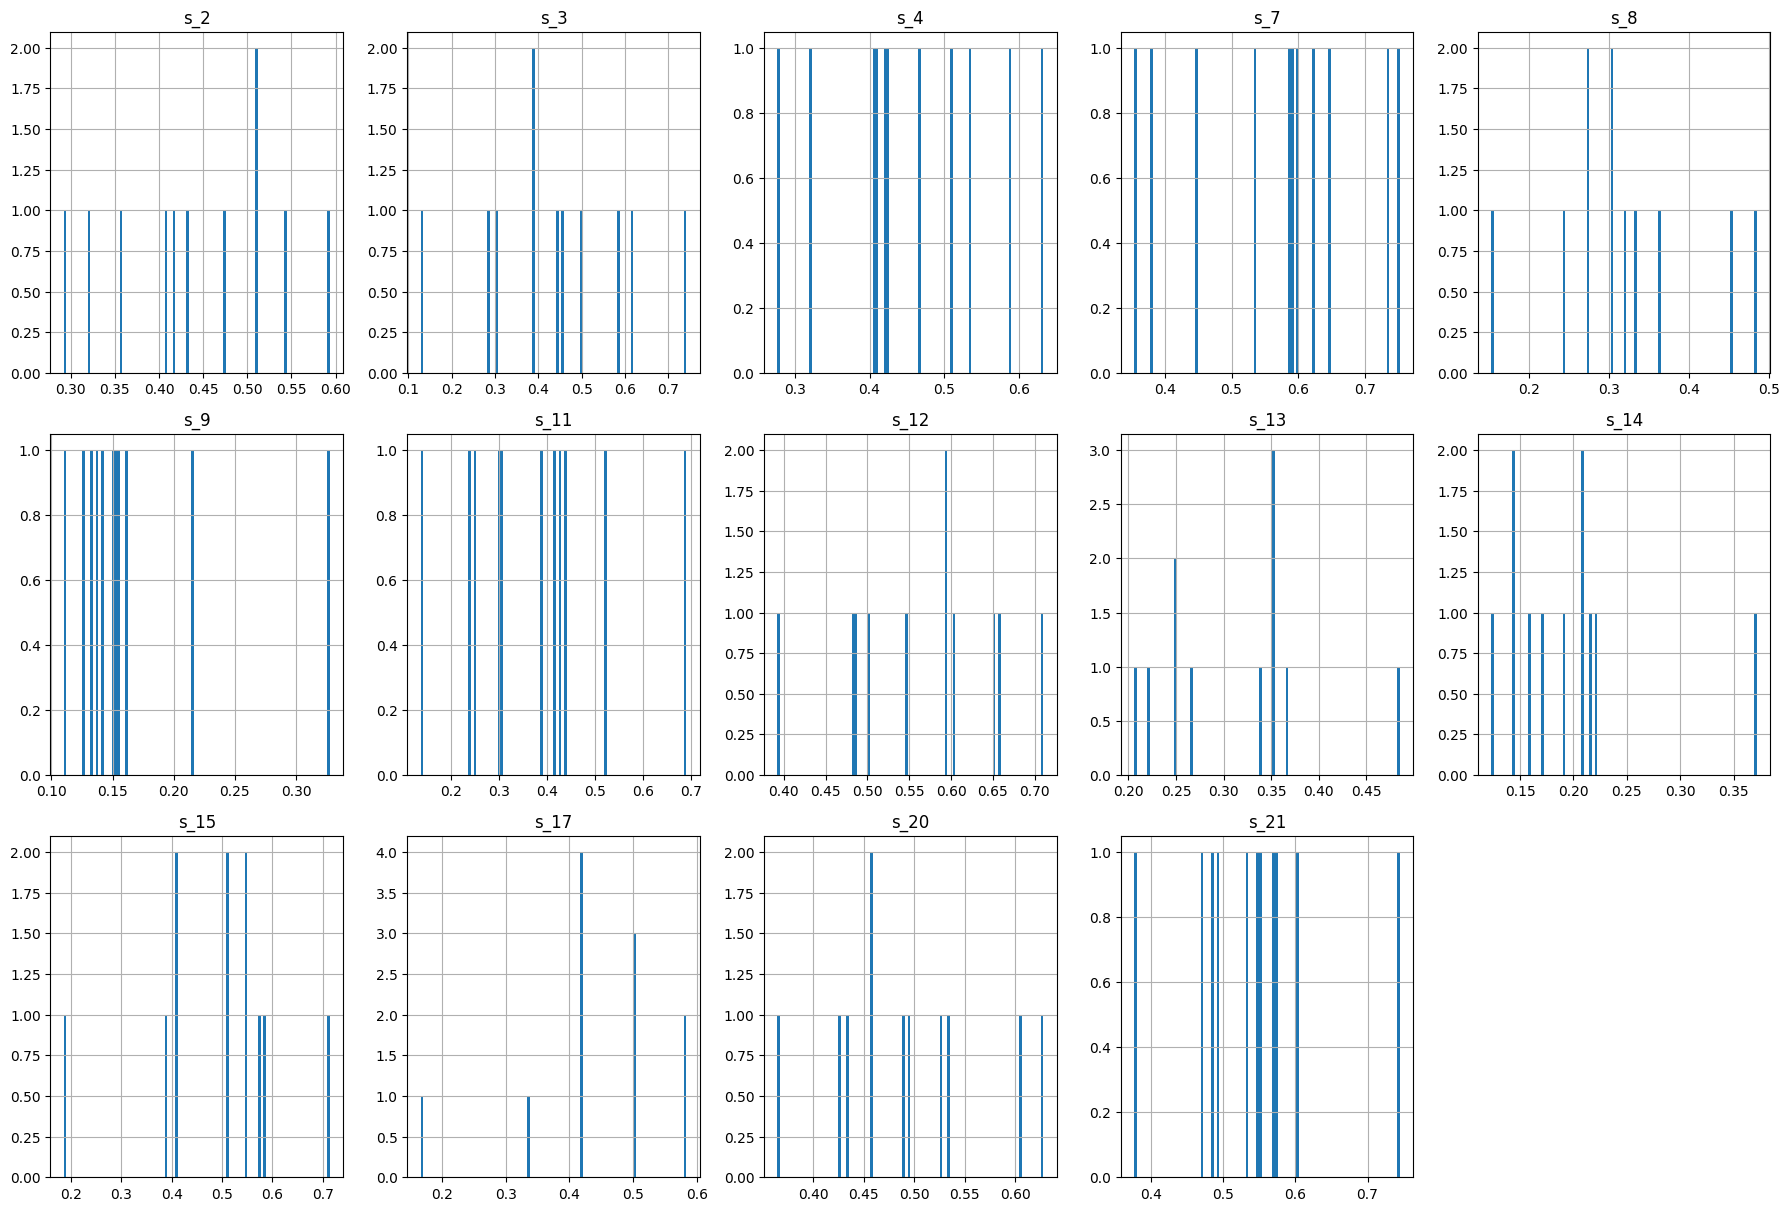

In [ ]:
from pyspark.ml.functions import vector_to_array
from pyspark.sql.functions import col
import matplotlib.pyplot as plt

# Convert the vector column to an array column
X_valid_s = X_valid_s.withColumn("features_array", vector_to_array(col("scaledFeatures")))

# Extract individual features into separate columns for the specified sensors
for i in range(2, 22):  # Assuming 's_1' is not required
    if i not in [1, 5, 6, 10, 16, 18, 19]:  # Exclude the sensors that are not needed
        X_valid_s = X_valid_s.withColumn(f's_{i}', col("features_array").getItem(i - 1))

# Sample the data
sampled_data = X_valid_s.sample(withReplacement=False, fraction=0.1, seed=42).toPandas()

# Define the sensor names that we are interested in plotting
sensor_names = [f's_{i}' for i in range(1, 22) if i not in [1, 5, 6, 10, 16, 18, 19]]

# Plot histograms for each sensor
fig, axes = plt.subplots(nrows=4, ncols=5, figsize=(18, 16))  # Adjust the layout based on the number of sensors
axes = axes.flatten()  # Flatten the axes array for easy iteration

# Iterate over the existing sensor columns and plot histograms
for i, sensor_name in enumerate(sensor_names):
    if sensor_name in sampled_data.columns:
        ax = axes[i]
        sampled_data[sensor_name].hist(bins=100, ax=ax)
        ax.set_title(sensor_name)
    else:
        print(f"{sensor_name} not found in the DataFrame.")

# Remove any extra subplots if there are fewer sensors than subplots
for i in range(len(sensor_names), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()


#Linear regression model

In [ ]:
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.feature import VectorAssembler, MinMaxScaler
from pyspark.ml import Pipeline
from pyspark.sql.functions import col

# Assuming df_with_RUL is your DataFrame which includes 'RUL' and sensor features
feature_columns = [col_name for col_name in df_with_RUL.columns if col_name not in ('unit_number', 'time_cycles', 'RUL')]

# Assemble features into a vector
assembler = VectorAssembler(inputCols=feature_columns, outputCol="features")

# Initialize the MinMaxScaler
scaler = MinMaxScaler(inputCol="features", outputCol="scaledFeatures")

# Define the pipeline that includes the assembler and the scaler
pipeline = Pipeline(stages=[assembler, scaler])

# Fit the pipeline to the entire dataset to include all min and max values
pipeline_model = pipeline.fit(df_with_RUL)

# Transform the dataset
df_transformed = pipeline_model.transform(df_with_RUL)

# Select the 'RUL' and 'scaledFeatures' for modeling
data_for_modeling = df_transformed.select(col("RUL"), col("scaledFeatures").alias("features"))

# Split the data into training and test sets
train_df, test_df = data_for_modeling.randomSplit([0.7, 0.3], seed=42)

# Initialize the Linear Regression model
lr = LinearRegression(featuresCol='features', labelCol='RUL')

# Fit the model on the training data
lr_model = lr.fit(train_df)

# Make predictions on the test data
lr_predictions = lr_model.transform(test_df)

# Initialize evaluators
evaluator_rmse = RegressionEvaluator(labelCol="RUL", predictionCol="prediction", metricName="rmse")
evaluator_r2 = RegressionEvaluator(labelCol="RUL", predictionCol="prediction", metricName="r2")
evaluator_mae = RegressionEvaluator(labelCol="RUL", predictionCol="prediction", metricName="mae")
evaluator_mse = RegressionEvaluator(labelCol="RUL", predictionCol="prediction", metricName="mse")

# Evaluate the model
rmse = evaluator_rmse.evaluate(lr_predictions)
r2 = evaluator_r2.evaluate(lr_predictions)
mae = evaluator_mae.evaluate(lr_predictions)
mse = evaluator_mse.evaluate(lr_predictions)

# Print the metrics
print(f"Linear Regression RMSE: {rmse:.3f}")
print(f"Linear Regression R2: {r2:.3f}")
print(f"Linear Regression MAE: {mae:.3f}")
print(f"Linear Regression MSE: {mse:.3f}")


Linear Regression RMSE: 44.945
Linear Regression R2: 0.571
Linear Regression MAE: 34.442
Linear Regression MSE: 2020.088


#Random forest model

In [ ]:
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator

# Continue using the 'data_for_modeling' DataFrame from the previous example
# which contains 'features' and 'RUL'

# Split the data into training and test sets
train_df, test_df = data_for_modeling.randomSplit([0.7, 0.3], seed=42)

# Initialize the Random Forest model
rf = RandomForestRegressor(featuresCol='features', labelCol='RUL', numTrees=20)

# Fit the model on the training data
rf_model = rf.fit(train_df)

# Make predictions on the test data
rf_predictions = rf_model.transform(test_df)

# Initialize evaluators
evaluator_rmse = RegressionEvaluator(labelCol="RUL", predictionCol="prediction", metricName="rmse")
evaluator_r2 = RegressionEvaluator(labelCol="RUL", predictionCol="prediction", metricName="r2")
evaluator_mae = RegressionEvaluator(labelCol="RUL", predictionCol="prediction", metricName="mae")
evaluator_mse = RegressionEvaluator(labelCol="RUL", predictionCol="prediction", metricName="mse")

# Evaluate the model
rmse = evaluator_rmse.evaluate(rf_predictions)
r2 = evaluator_r2.evaluate(rf_predictions)
mae = evaluator_mae.evaluate(rf_predictions)
mse = evaluator_mse.evaluate(rf_predictions)

# Print the metrics
print(f"Random Forest RMSE: {rmse:.3f}")
print(f"Random Forest R2: {r2:.3f}")
print(f"Random Forest MAE: {mae:.3f}")
print(f"Random Forest MSE: {mse:.3f}")


Random Forest RMSE: 42.871
Random Forest R2: 0.610
Random Forest MAE: 31.093
Random Forest MSE: 1837.898


# Support Vector Machine using LinearSVC class

In [ ]:
from pyspark.ml.classification import LinearSVC
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

# Convert RUL to binary labels for classification
threshold = 100  # Define a threshold for the binary classification
binary_train_df = train_df.withColumn('binary_label', (col('RUL') > threshold).cast('integer'))
binary_test_df = test_df.withColumn('binary_label', (col('RUL') > threshold).cast('integer'))

# Initialize the Linear SVC model
lsvc = LinearSVC(featuresCol='features', labelCol='binary_label')

# Fit the model on the training data
lsvc_model = lsvc.fit(binary_train_df)

# Make predictions on the test data
lsvc_predictions = lsvc_model.transform(binary_test_df)

# Initialize the evaluators
binary_evaluator = BinaryClassificationEvaluator(labelCol="binary_label", rawPredictionCol="prediction", metricName="areaUnderROC")
multiclass_evaluator = MulticlassClassificationEvaluator(labelCol="binary_label", predictionCol="prediction")

# Evaluate the model using AUC
auc = binary_evaluator.evaluate(lsvc_predictions)
print(f"SVM AUC: {auc:.3f}")

# Evaluate the model using other metrics
accuracy = multiclass_evaluator.evaluate(lsvc_predictions, {multiclass_evaluator.metricName: "accuracy"})
precision = multiclass_evaluator.evaluate(lsvc_predictions, {multiclass_evaluator.metricName: "precisionByLabel"})
recall = multiclass_evaluator.evaluate(lsvc_predictions, {multiclass_evaluator.metricName: "recallByLabel"})
f1 = multiclass_evaluator.evaluate(lsvc_predictions, {multiclass_evaluator.metricName: "f1"})

# Print the metrics
print(f"SVM Accuracy: {accuracy:.3f}")
print(f"SVM Precision: {precision:.3f}")
print(f"SVM Recall: {recall:.3f}")
print(f"SVM F1 Score: {f1:.3f}")


SVM AUC: 0.836
SVM Accuracy: 0.838
SVM Precision: 0.864
SVM Recall: 0.785
SVM F1 Score: 0.838


/usr/local/lib/python3.10/dist-packages/pyspark/sql/context.py:158: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


Precision: 0.819
Recall: 0.887
F1 Score: 0.852


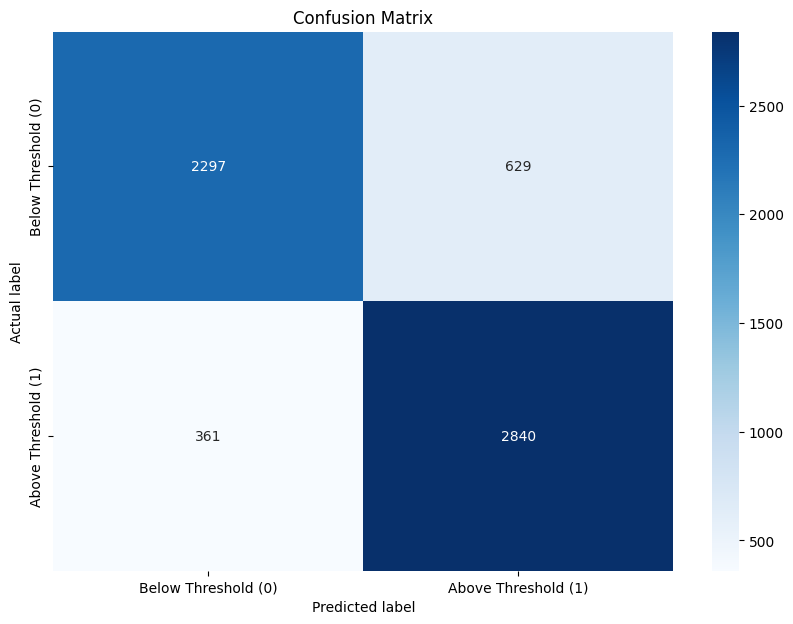

True Positives: 2840.0
False Positives: 629.0
True Negatives: 2297.0
False Negatives: 361.0


In [ ]:
from pyspark.sql.functions import col
from pyspark.mllib.evaluation import MulticlassMetrics
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'lsvc_predictions' is the DataFrame containing the output of the SVM model

# Cast the prediction and label columns to double type before converting to RDD for MulticlassMetrics
predictionAndLabels = lsvc_predictions.select(
    col("prediction").cast("double"),
    col("binary_label").cast("double")
).rdd.map(lambda row: (row[0], row[1]))

# Instantiate metrics object
metrics = MulticlassMetrics(predictionAndLabels)

# Compute the confusion matrix
confusion_matrix = metrics.confusionMatrix().toArray()

# Assuming that '1' corresponds to 'Above Threshold' and '0' corresponds to 'Below Threshold'
labels = ['Below Threshold (0)', 'Above Threshold (1)']

# Convert the confusion matrix to a DataFrame for plotting
df_cm = pd.DataFrame(confusion_matrix, index=labels, columns=labels)


# Calculate additional metrics from the confusion matrix
TP = confusion_matrix[1, 1]  # True Positives
FP = confusion_matrix[0, 1]  # False Positives
TN = confusion_matrix[0, 0]  # True Negatives
FN = confusion_matrix[1, 0]  # False Negatives

# Calculate precision, recall, and F1 score
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1 Score: {f1_score:.3f}")

# Plot the confusion matrix using seaborn
plt.figure(figsize=(10, 7))
sns.heatmap(df_cm, annot=True, fmt='g', cmap='Blues')  # 'fmt' is a string formatting code to format the numbers
plt.title('Confusion Matrix')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()


# Print the calculated precision, recall, and F1 score
print(f"True Positives: {TP}")
print(f"False Positives: {FP}")
print(f"True Negatives: {TN}")
print(f"False Negatives: {FN}")



In [ ]:
#5 fold cross validation

from pyspark.ml import Pipeline
from pyspark.ml.classification import LinearSVC
from pyspark.ml.feature import VectorAssembler, MinMaxScaler
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.sql.functions import col

# Assuming 'df_with_RUL' is your DataFrame which includes 'RUL' and all the sensor features
feature_columns = [col_name for col_name in df_with_RUL.columns if col_name not in ('unit_number', 'time_cycles', 'RUL')]

# Assemble features into a vector
assembler = VectorAssembler(inputCols=feature_columns, outputCol="features")

# Initialize the MinMaxScaler
scaler = MinMaxScaler(inputCol="features", outputCol="scaledFeatures")

# Convert RUL to binary labels for classification
# Using a threshold of 135 as mentioned
binary_df = df_with_RUL.withColumn('binary_label', (col('RUL') > 135).cast('integer'))

# Define the SVM model
svc = LinearSVC(labelCol='binary_label', featuresCol='scaledFeatures')

# Define the pipeline
pipeline = Pipeline(stages=[assembler, scaler, svc])

# Create the parameter grid for cross-validation
paramGrid = ParamGridBuilder() \
    .addGrid(svc.maxIter, [10, 100, 1000]) \
    .addGrid(svc.regParam, [0.01, 0.1, 0.5]) \
    .build()

# Define the evaluator
evaluator = BinaryClassificationEvaluator(labelCol='binary_label', rawPredictionCol="rawPrediction", metricName="areaUnderROC")

# Define the cross-validator
crossval = CrossValidator(estimator=pipeline,
                          estimatorParamMaps=paramGrid,
                          evaluator=evaluator,
                          numFolds=5)  # 5-fold cross-validation

# Run cross-validation, and choose the best set of parameters.
cvModel = crossval.fit(binary_df)

# Retrieve the average metric for each parameter setting
avg_metrics = cvModel.avgMetrics

# Print the average metrics for each fold and parameters set
for i, params in enumerate(paramGrid):
    print(f"Params (maxIter: {params[svc.maxIter]}, regParam: {params[svc.regParam]})")
    print(f"Avg metric (AUC) across folds: {avg_metrics[i]:.3f}")

# Get the best model from cross-validation
bestModel = cvModel.bestModel

# Use the best model to make predictions on the entire dataset
predictions = bestModel.transform(binary_df)

# Evaluate the best model on the dataset
auc = evaluator.evaluate(predictions)

# Print the best model's AUC
print(f"Best model's AUC: {auc:.3f}")



Params (maxIter: 10, regParam: 0.01)
Avg metric (AUC) across folds: 0.866
Params (maxIter: 10, regParam: 0.1)
Avg metric (AUC) across folds: 0.859
Params (maxIter: 10, regParam: 0.5)
Avg metric (AUC) across folds: 0.845
Params (maxIter: 100, regParam: 0.01)
Avg metric (AUC) across folds: 0.867
Params (maxIter: 100, regParam: 0.1)
Avg metric (AUC) across folds: 0.860
Params (maxIter: 100, regParam: 0.5)
Avg metric (AUC) across folds: 0.845
Params (maxIter: 1000, regParam: 0.01)
Avg metric (AUC) across folds: 0.867
Params (maxIter: 1000, regParam: 0.1)
Avg metric (AUC) across folds: 0.860
Params (maxIter: 1000, regParam: 0.5)
Avg metric (AUC) across folds: 0.845
Best model's AUC: 0.868


#Logistic Regression Classifier

In [ ]:
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

# Convert RUL to binary labels for classification
# Assuming the threshold of 135 as mentioned before
threshold = 135
binary_train_df = train_df.withColumn('binary_label', (col('RUL') > threshold).cast('integer'))
binary_test_df = test_df.withColumn('binary_label', (col('RUL') > threshold).cast('integer'))

# Initialize the Logistic Regression model
log_reg = LogisticRegression(featuresCol='features', labelCol='binary_label')

# Fit the model on the training data
log_reg_model = log_reg.fit(binary_train_df)

# Make predictions on the test data
log_reg_predictions = log_reg_model.transform(binary_test_df)

# Initialize the evaluators
binary_evaluator = BinaryClassificationEvaluator(labelCol="binary_label", rawPredictionCol="prediction", metricName="areaUnderROC")
multiclass_evaluator = MulticlassClassificationEvaluator(labelCol="binary_label", predictionCol="prediction")

# Evaluate the model using AUC
log_reg_auc = binary_evaluator.evaluate(log_reg_predictions)
print(f"Logistic Regression AUC: {log_reg_auc:.3f}")

# Evaluate other metrics
log_reg_accuracy = multiclass_evaluator.evaluate(log_reg_predictions, {multiclass_evaluator.metricName: "accuracy"})
log_reg_precision = multiclass_evaluator.evaluate(log_reg_predictions, {multiclass_evaluator.metricName: "precisionByLabel"})
log_reg_recall = multiclass_evaluator.evaluate(log_reg_predictions, {multiclass_evaluator.metricName: "recallByLabel"})
log_reg_f1 = multiclass_evaluator.evaluate(log_reg_predictions, {multiclass_evaluator.metricName: "f1"})

# Print the metrics
print(f"Logistic Regression Accuracy: {log_reg_accuracy:.3f}")
print(f"Logistic Regression Precision: {log_reg_precision:.3f}")
print(f"Logistic Regression Recall: {log_reg_recall:.3f}")
print(f"Logistic Regression F1 Score: {log_reg_f1:.3f}")


Logistic Regression AUC: 0.741
Logistic Regression Accuracy: 0.773
Logistic Regression Precision: 0.810
Logistic Regression Recall: 0.849
Logistic Regression F1 Score: 0.770


/usr/local/lib/python3.10/dist-packages/pyspark/sql/context.py:158: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


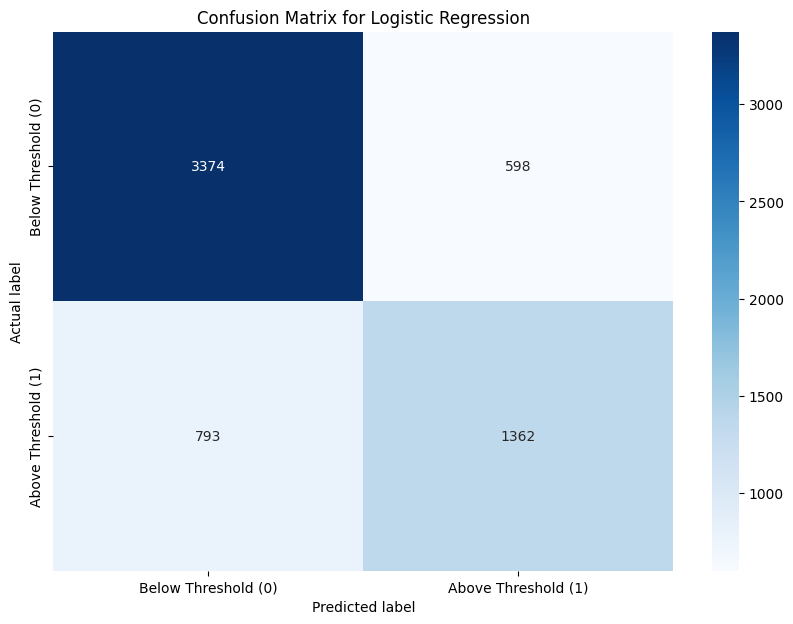

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from pyspark.mllib.evaluation import MulticlassMetrics
from pyspark.sql.functions import col

# Convert predictions and labels to an RDD of (prediction, label) pairs
predictionAndLabels = log_reg_predictions.select(
    col("prediction").cast("double"),
    col("binary_label").cast("double")
).rdd.map(lambda row: (row[0], row[1]))

# Instantiate metrics object
metrics = MulticlassMetrics(predictionAndLabels)

# Compute the confusion matrix
confusion_matrix = metrics.confusionMatrix().toArray()

# Define labels based on the SVM results you shared
labels = ['Below Threshold (0)', 'Above Threshold (1)']

# Convert the confusion matrix to a DataFrame for plotting
df_cm = pd.DataFrame(confusion_matrix, index=labels, columns=labels)

# Plot the confusion matrix using seaborn
plt.figure(figsize=(10, 7))
sns.heatmap(df_cm, annot=True, fmt='g', cmap='Blues')  # 'fmt' specifies the number formatting
plt.title('Confusion Matrix for Logistic Regression')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()


In [ ]:
#5fold cross validation

from pyspark.ml import Pipeline
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.feature import VectorAssembler, MinMaxScaler
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.sql.functions import col

# Assuming 'df_with_RUL' is your DataFrame which includes 'RUL' and all the sensor features
feature_columns = [col_name for col_name in df_with_RUL.columns if col_name not in ('unit_number', 'time_cycles', 'RUL')]

# Assemble features into a vector
assembler = VectorAssembler(inputCols=feature_columns, outputCol="features")

# Initialize the MinMaxScaler
scaler = MinMaxScaler(inputCol="features", outputCol="scaledFeatures")

# Convert RUL to binary labels for classification
# Using a threshold of 135 as mentioned
binary_df = df_with_RUL.withColumn('binary_label', (col('RUL') > 135).cast('integer'))

# Define the Logistic Regression model
logistic_reg = LogisticRegression(labelCol='binary_label', featuresCol='scaledFeatures')

# Define the pipeline
pipeline = Pipeline(stages=[assembler, scaler, logistic_reg])

# Create the parameter grid for cross-validation
paramGrid = ParamGridBuilder() \
    .addGrid(logistic_reg.maxIter, [10, 50, 100]) \
    .addGrid(logistic_reg.regParam, [0.01, 0.1, 0.5]) \
    .addGrid(logistic_reg.elasticNetParam, [0.0, 0.5, 1.0]) \
    .build()

# Define the evaluator
evaluator = BinaryClassificationEvaluator(labelCol='binary_label', rawPredictionCol="rawPrediction", metricName="areaUnderROC")

# Define the cross-validator
crossval = CrossValidator(estimator=pipeline,
                          estimatorParamMaps=paramGrid,
                          evaluator=evaluator,
                          numFolds=5)  # 5-fold cross-validation

# Run cross-validation, and choose the best set of parameters.
cvModel = crossval.fit(binary_df)

# Retrieve the average metric for each parameter setting
avg_metrics = cvModel.avgMetrics

# Print the average metrics for each fold and parameters set
for i, params in enumerate(paramGrid):
    print(f"Params (maxIter: {params[logistic_reg.maxIter]}, regParam: {params[logistic_reg.regParam]}, "
          f"elasticNetParam: {params[logistic_reg.elasticNetParam]})")
    print(f"Avg metric (AUC) across folds: {avg_metrics[i]:.3f}")

# Get the best model from cross-validation
bestModel = cvModel.bestModel

# Use the best model to make predictions on the entire dataset
predictions = bestModel.transform(binary_df)

# Evaluate the best model on the dataset
auc = evaluator.evaluate(predictions)

# Print the best model's AUC
print(f"Best model's AUC: {auc:.3f}")


Params (maxIter: 10, regParam: 0.01, elasticNetParam: 0.0)
Avg metric (AUC) across folds: 0.867
Params (maxIter: 10, regParam: 0.01, elasticNetParam: 0.5)
Avg metric (AUC) across folds: 0.867
Params (maxIter: 10, regParam: 0.01, elasticNetParam: 1.0)
Avg metric (AUC) across folds: 0.867
Params (maxIter: 10, regParam: 0.1, elasticNetParam: 0.0)
Avg metric (AUC) across folds: 0.857
Params (maxIter: 10, regParam: 0.1, elasticNetParam: 0.5)
Avg metric (AUC) across folds: 0.845
Params (maxIter: 10, regParam: 0.1, elasticNetParam: 1.0)
Avg metric (AUC) across folds: 0.825
Params (maxIter: 10, regParam: 0.5, elasticNetParam: 0.0)
Avg metric (AUC) across folds: 0.844
Params (maxIter: 10, regParam: 0.5, elasticNetParam: 0.5)
Avg metric (AUC) across folds: 0.500
Params (maxIter: 10, regParam: 0.5, elasticNetParam: 1.0)
Avg metric (AUC) across folds: 0.500
Params (maxIter: 50, regParam: 0.01, elasticNetParam: 0.0)
Avg metric (AUC) across folds: 0.867
Params (maxIter: 50, regParam: 0.01, elasticNe

#LSTM

In [ ]:
pip install elephas


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 7.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 17.2 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.9.0
    Uninstalling h5py-3.9.0:
      Successfully uninstalled h5py-3.9.0
  Attempting uninstall: Cython
    Found existing installation: Cython 3.0.5
    Uninstalling Cython-3.0.5:
      Successfully uninstalled Cython-3.0.5


In [ ]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Assuming 'df_transformed' is the DataFrame obtained after scaling in the Random Forest example
# and it contains 'scaledFeatures' as the scaled sensor readings and 'RUL'

# Convert the Spark DataFrame to a Pandas DataFrame for easier manipulation
df_transformed_pd = df_transformed.select("features", "RUL").toPandas()

# Extract features and RUL from the DataFrame
X = np.array(df_transformed_pd['features'].tolist())
y = df_transformed_pd['RUL'].values

# Reshape X for LSTM [samples, time steps, features]
X = X.reshape((X.shape[0], 1, X.shape[1]))

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create LSTM model
model = Sequential()
model.add(LSTM(50, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')

# Fit the model
model.fit(X_train, y_train, epochs=100, batch_size=64, validation_data=(X_test, y_test), verbose=2)

# Make predictions
y_pred = model.predict(X_test)

# Calculate metrics

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)  # RMSE is just the square root of MSE
mae = mean_absolute_error(y_test, y_pred)

print(f"LSTM RMSE: {mse}")
print(f"R^2: {r2}")
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")

Epoch 1/100
226/226 - 4s - loss: 15911.2822 - val_loss: 15691.8975 - 4s/epoch - 17ms/step
Epoch 2/100
226/226 - 1s - loss: 15336.3203 - val_loss: 15120.9443 - 720ms/epoch - 3ms/step
Epoch 3/100
226/226 - 1s - loss: 14783.1963 - val_loss: 14569.9531 - 901ms/epoch - 4ms/step
Epoch 4/100
226/226 - 1s - loss: 14250.6357 - val_loss: 14040.3672 - 1s/epoch - 5ms/step
Epoch 5/100
226/226 - 1s - loss: 13738.9014 - val_loss: 13530.0967 - 1s/epoch - 5ms/step
Epoch 6/100
226/226 - 1s - loss: 13246.2871 - val_loss: 13040.4277 - 1s/epoch - 5ms/step
Epoch 7/100
226/226 - 1s - loss: 12772.2236 - val_loss: 12567.2441 - 1s/epoch - 5ms/step
Epoch 8/100
226/226 - 1s - loss: 12316.3633 - val_loss: 12112.6240 - 1s/epoch - 5ms/step
Epoch 9/100
226/226 - 1s - loss: 11877.6719 - val_loss: 11674.8301 - 1s/epoch - 5ms/step
Epoch 10/100
226/226 - 1s - loss: 11456.1611 - val_loss: 11255.1084 - 1s/epoch - 5ms/step
Epoch 11/100
226/226 - 1s - loss: 11050.9492 - val_loss: 10849.4453 - 889ms/epoch - 4ms/step
Epoch 12/